In [1]:
import pandas as pd

# excel file containing raw and cleaned GoogleAds sales data
file_path = "GoogleAds_Sales_Data.xlsx" 
sheet_name = "GoogleAds_Sales_Cleaned" # data cleansing done in excel

df = pd.read_excel(file_path, sheet_name=sheet_name)

df

,Ad_ID,Campaign_Name,Clicks,Impressions,CTR,Cost,has_dollarSign?,Leads,Conversions,Conversion Rate,...,Added_Conversion_Rates,Sale_Amount,has_dollarSign?.1,Ad_Date,New_Ad_Date,Location,New_Location,Device,New_Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,0.02312,231.88,True,14.0,7.0,0.058,...,0.058,1892.0,True,2024-11-16 00:00:00,2024-11-16,hyderabad,Hyderabad,desktop,Desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,0.03388,216.84,True,10.0,8.0,0.046,...,0.046,1679.0,True,20-11-2024,2024-11-20,hyderabad,Hyderabad,mobile,Mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,0.01981,203.66,True,26.0,9.0,NaN,...,0.100,1624.0,True,2024-11-16 00:00:00,2024-11-16,hyderabad,Hyderabad,Desktop,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,0.04458,237.66,True,17.0,6.0,NaN,...,0.042,1225.0,True,2024-11-26 00:00:00,2024-11-26,HYDERABAD,Hyderabad,tablet,Tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,0.04641,195.90,True,30.0,8.0,NaN,...,0.051,1091.0,True,2024-11-22 00:00:00,2024-11-22,hyderabad,Hyderabad,desktop,Desktop,online data analytic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,DataAnalyticsCourse,88.0,5344.0,0.01647,242.07,True,17.0,9.0,0.054,...,0.054,1418.0,True,29-11-2024,2024-11-29,HYDERABAD,Hyderabad,MOBILE,Mobile,online data analytic
2596,A3596,DataAnalyticsCourse,154.0,3211.0,0.04796,248.28,True,14.0,6.0,0.039,...,0.039,1950.0,True,2024-11-28 00:00:00,2024-11-28,hyderabad,Hyderabad,TABLET,Tablet,data analitics online
2597,A3597,Data Anlytics Corse,113.0,3808.0,0.02967,233.25,True,18.0,4.0,0.035,...,0.035,1085.0,True,2024-11-02 00:00:00,2024-11-02,Hyderbad,Hyderabad,desktop,Desktop,data anaytics training
2598,A3598,Data Analytics Corse,196.0,5853.0,0.03349,220.13,True,16.0,7.0,0.036,...,0.036,1558.0,True,2024-11-08 00:00:00,2024-11-08,hydrebad,Hyderabad,Tablet,Tablet,data anaytics training


In [3]:
rename_old_columns = {
    "Ad_Date": "Ad_Date_original",  # Using '_original' to clearly indicate the old column
    "Location": "Location_original",
    "Device": "Device_original"
}
# Only attempt to rename if the column exists to prevent KeyError if user already modified
existing_old_cols = {k: v for k, v in rename_old_columns.items() if k in df.columns}
if existing_old_cols:
    df = df.rename(columns=existing_old_cols)
    print("\nRenamed original columns to temporary names.")


# Rename the "New_[]" versions of the columns to their final desired names
rename_new_columns = {
    "New_Ad_Date": "Ad_Date",
    "New_Location": "Location",
    "New_Device": "Device"
}
# Only attempt to rename if the 'New_' column exists
existing_new_cols = {k: v for k, v in rename_new_columns.items() if k in df.columns}
if existing_new_cols:
    df = df.rename(columns=existing_new_cols)
    print("Renamed 'New_' columns to their final names.")


# Define the list of all columns to be deleted, including the temporarily renamed ones
columns_to_delete = [
    "Ad_Date_original",
    "Location_original",
    "Device_original",
    "has_dollarSign?",
    "has_dollarSign?.1"
]

# `errors='ignore'` ensures that if a column doesn't exist (e.g., it was already deleted or misnamed),
# the operation won't raise an error.
df = df.drop(columns=columns_to_delete, errors='ignore')
df


Renamed original columns to temporary names.
Renamed 'New_' columns to their final names.


,Ad_ID,Campaign_Name,Clicks,Impressions,CTR,Cost,Leads,Conversions,Conversion Rate,Updated Conversion Rates,Conversion_Rates Differences,Added_Conversion_Rates,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,0.02312,231.88,14.0,7.0,0.058,0.067,0.009,0.058,1892.0,2024-11-16,Hyderabad,Desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,0.03388,216.84,10.0,8.0,0.046,0.046,0.000,0.046,1679.0,2024-11-20,Hyderabad,Mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,0.01981,203.66,26.0,9.0,NaN,0.100,NaN,0.100,1624.0,2024-11-16,Hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,0.04458,237.66,17.0,6.0,NaN,0.042,NaN,0.042,1225.0,2024-11-26,Hyderabad,Tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,0.04641,195.90,30.0,8.0,NaN,0.051,NaN,0.051,1091.0,2024-11-22,Hyderabad,Desktop,online data analytic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,DataAnalyticsCourse,88.0,5344.0,0.01647,242.07,17.0,9.0,0.054,0.102,0.048,0.054,1418.0,2024-11-29,Hyderabad,Mobile,online data analytic
2596,A3596,DataAnalyticsCourse,154.0,3211.0,0.04796,248.28,14.0,6.0,0.039,0.039,0.000,0.039,1950.0,2024-11-28,Hyderabad,Tablet,data analitics online
2597,A3597,Data Anlytics Corse,113.0,3808.0,0.02967,233.25,18.0,4.0,0.035,0.035,0.000,0.035,1085.0,2024-11-02,Hyderabad,Desktop,data anaytics training
2598,A3598,Data Analytics Corse,196.0,5853.0,0.03349,220.13,16.0,7.0,0.036,0.036,0.000,0.036,1558.0,2024-11-08,Hyderabad,Tablet,data anaytics training


In [5]:
# Columns addded: 
# CTR (Clicks / impressions)
# Updated Conversion Rates (Conversions / Clicks) ~ did this to fill in empty conversion rates but ones already filled don't always match
# Conversion_Rates Differences (Updated - Conversion_Rates) ~ to see how far off the formula is from the initial conversion rate, and to see which column I should go with
#### greatest negative difference: -0.04 & greatest positive difference: +0.089 ~ so going to go with the next column of conversion rates
# Added_Conversion_Rates: keeping initial entries in conversion rates the same and using the (conversions/clicks) formula to fill in the rest, besides rows without clicks or conversions entered
## Fixes: "Ad_Date" normalized to (YYYY-MM-DD), "Location" corrected - other spelling variations didn't exist, "Device" capitalization normalized
# To be fixed: Cleansing of columns "Campaign_Name" and "Keyword" by correcting spelling and formatting issues in order to group and analyze more easily.

# Basic cleaning for 'campaign_name'
if 'Campaign_Name' in df.columns:
    df['Campaign_Name'] = df['Campaign_Name'].str.title().str.strip().str.replace('_', ' ', regex=False)
    print("Cleaned 'Campaign_Name': converted to proper casing, stripped whitespace, and replaced underscores with spaces.")
else:
    print("Warning: 'Campaign_Name' column not found for cleaning.")

# Basic cleaning for 'keyword'
if 'Keyword' in df.columns:
    df['Keyword'] = df['Keyword'].str.title().str.strip() 
    # we split the string into a list of words, sort them alphabetically, and join them back.
    df['Sorted_Keyword'] = df['Keyword'].apply(lambda x: ' '.join(sorted(x.split())))
    print("Cleaned 'Keyword': converted to proper casing, stripped whitespace, and made a new column of sorted keywords")
else:
    print("Warning: 'Keyword' column not found for cleaning.") 

df 

Cleaned 'Campaign_Name': converted to proper casing, stripped whitespace, and replaced underscores with spaces.
Cleaned 'Keyword': converted to proper casing, stripped whitespace, and made a new column of sorted keywords


,Ad_ID,Campaign_Name,Clicks,Impressions,CTR,Cost,Leads,Conversions,Conversion Rate,Updated Conversion Rates,Conversion_Rates Differences,Added_Conversion_Rates,Sale_Amount,Ad_Date,Location,Device,Keyword,Sorted_Keyword
0,A1000,Dataanalyticscourse,104.0,4498.0,0.02312,231.88,14.0,7.0,0.058,0.067,0.009,0.058,1892.0,2024-11-16,Hyderabad,Desktop,Learn Data Analytics,Analytics Data Learn
1,A1001,Dataanalyticscourse,173.0,5107.0,0.03388,216.84,10.0,8.0,0.046,0.046,0.000,0.046,1679.0,2024-11-20,Hyderabad,Mobile,Data Analytics Course,Analytics Course Data
2,A1002,Data Anlytics Corse,90.0,4544.0,0.01981,203.66,26.0,9.0,NaN,0.100,NaN,0.100,1624.0,2024-11-16,Hyderabad,Desktop,Data Analitics Online,Analitics Data Online
3,A1003,Data Analytcis Course,142.0,3185.0,0.04458,237.66,17.0,6.0,NaN,0.042,NaN,0.042,1225.0,2024-11-26,Hyderabad,Tablet,Data Anaytics Training,Anaytics Data Training
4,A1004,Data Analytics Corse,156.0,3361.0,0.04641,195.90,30.0,8.0,NaN,0.051,NaN,0.051,1091.0,2024-11-22,Hyderabad,Desktop,Online Data Analytic,Analytic Data Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,Dataanalyticscourse,88.0,5344.0,0.01647,242.07,17.0,9.0,0.054,0.102,0.048,0.054,1418.0,2024-11-29,Hyderabad,Mobile,Online Data Analytic,Analytic Data Online
2596,A3596,Dataanalyticscourse,154.0,3211.0,0.04796,248.28,14.0,6.0,0.039,0.039,0.000,0.039,1950.0,2024-11-28,Hyderabad,Tablet,Data Analitics Online,Analitics Data Online
2597,A3597,Data Anlytics Corse,113.0,3808.0,0.02967,233.25,18.0,4.0,0.035,0.035,0.000,0.035,1085.0,2024-11-02,Hyderabad,Desktop,Data Anaytics Training,Anaytics Data Training
2598,A3598,Data Analytics Corse,196.0,5853.0,0.03349,220.13,16.0,7.0,0.036,0.036,0.000,0.036,1558.0,2024-11-08,Hyderabad,Tablet,Data Anaytics Training,Anaytics Data Training


In [7]:
print("\n--- Identifying Unique Values for Manual Correction ---")
if 'Campaign_Name' in df.columns:
    print("Unique values in 'Campaign_Name' after basic cleaning:")
    # Sort the unique values for a cleaner look
    print(sorted(df['Campaign_Name'].unique()))
if 'Keyword' in df.columns:
    print("\nUnique values in 'Keyword' after basic cleaning:")
    # Sort the unique values for a cleaner look
    print(sorted(df['Keyword'].unique()))



--- Identifying Unique Values for Manual Correction ---
Unique values in 'Campaign_Name' after basic cleaning:
['Data Analytcis Course', 'Data Analytics Corse', 'Data Anlytics Corse', 'Dataanalyticscourse']

Unique values in 'Keyword' after basic cleaning:
['Analytics For Data', 'Data Analitics Online', 'Data Analytics Course', 'Data Anaytics Training', 'Learn Data Analytics', 'Online Data Analytic']


In [9]:
print("\nCorrecting spelling errors in 'campaign_name' and 'keyword'...")

# dictionary for known campaign name corrections
campaign_name_corrections = {
    "Data Analytcis Course": "Data Analytics Course",
    "Data Analytics Corse": "Data Analytics Course",
    "Data Anlytics Corse": "Data Analytics Course",
    "Dataanalyticscourse": "Data Analytics Course"
}

# dictionary for known keyword corrections
keyword_corrections = {
    "Data Analitics Online": "Data Analytics Online",
    "Data Anaytics Training": "Data Analytics Training",
    "Online Data Analytic": "Online Data Analytics"
}

# Applying the corrections to the DataFrame
if 'Campaign_Name' in df.columns:
    df['Campaign_Name'] = df['Campaign_Name'].map(campaign_name_corrections).fillna(df['Campaign_Name'])
    print("Applied manual spelling corrections to 'Campaign_Name'.")
if 'Keyword' in df.columns:
    df['Keyword'] = df['Keyword'].map(keyword_corrections).fillna(df['Keyword'])
    print("Applied manual spelling corrections to 'Keyword'.")
if 'Sorted_Keyword' and 'Keyword' in df.columns:
    df['Sorted_Keyword'] = df['Keyword'].apply(
        lambda x: x if ((x == "Analytics For Data") or (x == "Data Analytics Training") or (x == "Data Analytics Course")) else ' '.join(sorted(x.split(), reverse=True))
    )
    print("Applied corrected spelling to 'Sorted_Keyword' column with descending sort, keeping 'Analytics For Data', 'Data Analytics Training', and 'Data Analytics Course' intact.")

df


Correcting spelling errors in 'campaign_name' and 'keyword'...
Applied manual spelling corrections to 'Campaign_Name'.
Applied manual spelling corrections to 'Keyword'.
Applied corrected spelling to 'Sorted_Keyword' column with descending sort, keeping 'Analytics For Data', 'Data Analytics Training', and 'Data Analytics Course' intact.


,Ad_ID,Campaign_Name,Clicks,Impressions,CTR,Cost,Leads,Conversions,Conversion Rate,Updated Conversion Rates,Conversion_Rates Differences,Added_Conversion_Rates,Sale_Amount,Ad_Date,Location,Device,Keyword,Sorted_Keyword
0,A1000,Data Analytics Course,104.0,4498.0,0.02312,231.88,14.0,7.0,0.058,0.067,0.009,0.058,1892.0,2024-11-16,Hyderabad,Desktop,Learn Data Analytics,Learn Data Analytics
1,A1001,Data Analytics Course,173.0,5107.0,0.03388,216.84,10.0,8.0,0.046,0.046,0.000,0.046,1679.0,2024-11-20,Hyderabad,Mobile,Data Analytics Course,Data Analytics Course
2,A1002,Data Analytics Course,90.0,4544.0,0.01981,203.66,26.0,9.0,NaN,0.100,NaN,0.100,1624.0,2024-11-16,Hyderabad,Desktop,Data Analytics Online,Online Data Analytics
3,A1003,Data Analytics Course,142.0,3185.0,0.04458,237.66,17.0,6.0,NaN,0.042,NaN,0.042,1225.0,2024-11-26,Hyderabad,Tablet,Data Analytics Training,Data Analytics Training
4,A1004,Data Analytics Course,156.0,3361.0,0.04641,195.90,30.0,8.0,NaN,0.051,NaN,0.051,1091.0,2024-11-22,Hyderabad,Desktop,Online Data Analytics,Online Data Analytics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,Data Analytics Course,88.0,5344.0,0.01647,242.07,17.0,9.0,0.054,0.102,0.048,0.054,1418.0,2024-11-29,Hyderabad,Mobile,Online Data Analytics,Online Data Analytics
2596,A3596,Data Analytics Course,154.0,3211.0,0.04796,248.28,14.0,6.0,0.039,0.039,0.000,0.039,1950.0,2024-11-28,Hyderabad,Tablet,Data Analytics Online,Online Data Analytics
2597,A3597,Data Analytics Course,113.0,3808.0,0.02967,233.25,18.0,4.0,0.035,0.035,0.000,0.035,1085.0,2024-11-02,Hyderabad,Desktop,Data Analytics Training,Data Analytics Training
2598,A3598,Data Analytics Course,196.0,5853.0,0.03349,220.13,16.0,7.0,0.036,0.036,0.000,0.036,1558.0,2024-11-08,Hyderabad,Tablet,Data Analytics Training,Data Analytics Training


In [11]:
print("\n--- Checking Spelling Corrections ---")
if 'Campaign_Name' in df.columns:
    print("Unique values in 'Campaign_Name' after cleaning:")
    # Sort the unique values for a cleaner look
    print(sorted(df['Campaign_Name'].unique()))
if 'Keyword' in df.columns:
    print("\nUnique values in 'Keyword' after cleaning:")
    # Sort the unique values for a cleaner look
    print(sorted(df['Keyword'].unique())) 
if 'Sorted_Keyword' in df.columns:
    print("\nUnique values in 'Sorted_Keyword' after cleaning:")
    # Sort the unique values for a cleaner look
    print(sorted(df['Sorted_Keyword'].unique())) 

# since ran and got desired results, will now delete keyword and rename 'Sorted_Keyword' to 'Keyword'
# Drop the 'Keyword' column
df = df.drop(columns=['Keyword'])

# Rename the 'Sorted_Keyword' column to 'Keyword'
df = df.rename(columns={'Sorted_Keyword': 'Keyword'})


--- Checking Spelling Corrections ---
Unique values in 'Campaign_Name' after cleaning:
['Data Analytics Course']

Unique values in 'Keyword' after cleaning:
['Analytics For Data', 'Data Analytics Course', 'Data Analytics Online', 'Data Analytics Training', 'Learn Data Analytics', 'Online Data Analytics']

Unique values in 'Sorted_Keyword' after cleaning:
['Analytics For Data', 'Data Analytics Course', 'Data Analytics Training', 'Learn Data Analytics', 'Online Data Analytics']


In [13]:
import numpy as np

# adding a ROAS (Return On Ad Spend ~ basically ROI) column 
if 'Cost' in df.columns and 'Sale_Amount' in df.columns:
    df['ROAS'] = np.where(
        (df['Cost'] > 0) & (df['Sale_Amount'] > 0),   # Condition: if Cost is greater than 0
        round(df['Cost'] / df['Sale_Amount'], 3),   # Value if True
        0                                           # Value if False (including if Cost is 0 or NaN)
    )
    print("\nCalculated 'ROAS' column, ensuring calculation only when Cost & Sale_Amount > 0.")
else:
    print("\nWarning: 'Cost' or 'Sale_Amount' columns not found. Skipping ROAS calculation.")

# adding a Profit column (Sale_Amount - Cost)
if 'Cost' in df.columns and 'Sale_Amount' in df.columns: 
    df['Profit'] = np.where(
        (df['Cost'] > 0) & (df['Sale_Amount'] > 0),
        df['Sale_Amount'] - df['Cost'],
        0
    )
    print("\nCalculated 'Profit' column, ensuring calculations only when Cost & Sale_Amount > 0.")
else: 
    print("\nWarning: 'Cost' or 'Sale_Amount' columns not found. Skipping Profit calculation.")

# adding a CPA column (Cost Per Acquisition ~ Cost / Conversions) 
if 'Cost' in df.columns and 'Conversions' in df.columns: 
    df['CPA'] = np.where(
        (df['Cost'] > 0) & (df['Conversions'] > 0),
        round(df['Cost'] / df['Conversions'], 3),
        0
    )
    print("\nCalculated 'CPA' column, ensuring calculations only when Cost & Conversions > 0.")
else: 
    print("\nWarning: 'Cost' or 'Conversions' columns not found. Skipping CPA calculation.")

df


Calculated 'ROAS' column, ensuring calculation only when Cost & Sale_Amount > 0.

Calculated 'Profit' column, ensuring calculations only when Cost & Sale_Amount > 0.

Calculated 'CPA' column, ensuring calculations only when Cost & Conversions > 0.


,Ad_ID,Campaign_Name,Clicks,Impressions,CTR,Cost,Leads,Conversions,Conversion Rate,Updated Conversion Rates,Conversion_Rates Differences,Added_Conversion_Rates,Sale_Amount,Ad_Date,Location,Device,Keyword,ROAS,Profit,CPA
0,A1000,Data Analytics Course,104.0,4498.0,0.02312,231.88,14.0,7.0,0.058,0.067,0.009,0.058,1892.0,2024-11-16,Hyderabad,Desktop,Learn Data Analytics,0.123,1660.12,33.126
1,A1001,Data Analytics Course,173.0,5107.0,0.03388,216.84,10.0,8.0,0.046,0.046,0.000,0.046,1679.0,2024-11-20,Hyderabad,Mobile,Data Analytics Course,0.129,1462.16,27.105
2,A1002,Data Analytics Course,90.0,4544.0,0.01981,203.66,26.0,9.0,NaN,0.100,NaN,0.100,1624.0,2024-11-16,Hyderabad,Desktop,Online Data Analytics,0.125,1420.34,22.629
3,A1003,Data Analytics Course,142.0,3185.0,0.04458,237.66,17.0,6.0,NaN,0.042,NaN,0.042,1225.0,2024-11-26,Hyderabad,Tablet,Data Analytics Training,0.194,987.34,39.610
4,A1004,Data Analytics Course,156.0,3361.0,0.04641,195.90,30.0,8.0,NaN,0.051,NaN,0.051,1091.0,2024-11-22,Hyderabad,Desktop,Online Data Analytics,0.180,895.10,24.488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,A3595,Data Analytics Course,88.0,5344.0,0.01647,242.07,17.0,9.0,0.054,0.102,0.048,0.054,1418.0,2024-11-29,Hyderabad,Mobile,Online Data Analytics,0.171,1175.93,26.897
2596,A3596,Data Analytics Course,154.0,3211.0,0.04796,248.28,14.0,6.0,0.039,0.039,0.000,0.039,1950.0,2024-11-28,Hyderabad,Tablet,Online Data Analytics,0.127,1701.72,41.380
2597,A3597,Data Analytics Course,113.0,3808.0,0.02967,233.25,18.0,4.0,0.035,0.035,0.000,0.035,1085.0,2024-11-02,Hyderabad,Desktop,Data Analytics Training,0.215,851.75,58.312
2598,A3598,Data Analytics Course,196.0,5853.0,0.03349,220.13,16.0,7.0,0.036,0.036,0.000,0.036,1558.0,2024-11-08,Hyderabad,Tablet,Data Analytics Training,0.141,1337.87,31.447


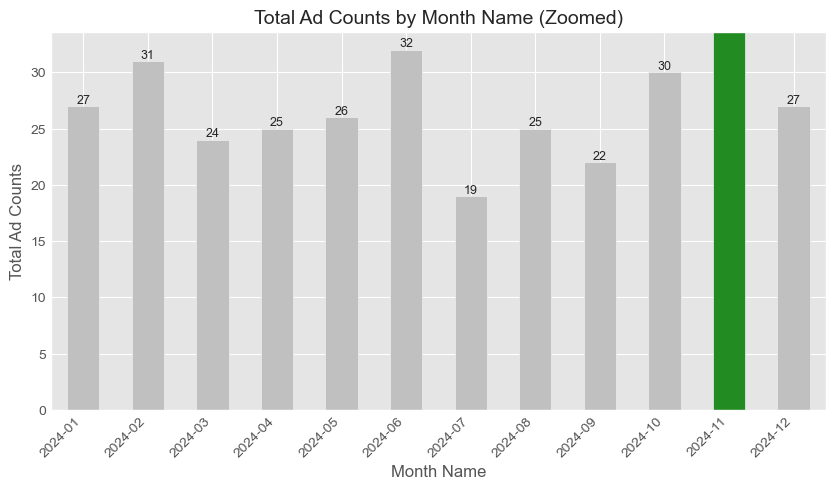


--- Report for the entire dataset ---

===== Report for All Data =====

--- Summary of Data ---
Clicks                         (Sum): 345,725       (100.00%)
Clicks                         (Avg): 132
---------------------------------------------
Impressions                    (Sum): 11,516,273    (100.00%)
Impressions                    (Avg): 4,429
---------------------------------------------
Leads                          (Sum): 51,050        (100.00%)
Leads                          (Avg): 20
---------------------------------------------
Conversions                    (Sum): 16,467        (100.00%)
Conversions                    (Avg): 6
---------------------------------------------
Cost                           (Sum): $538,371.83   (100.00%)
Cost                           (Avg): $207.07
---------------------------------------------
Sale_Amount                    (Sum): $3,688,173.00 (100.00%)
Sale_Amount                    (Avg): $1,418.53
----------------------------------------

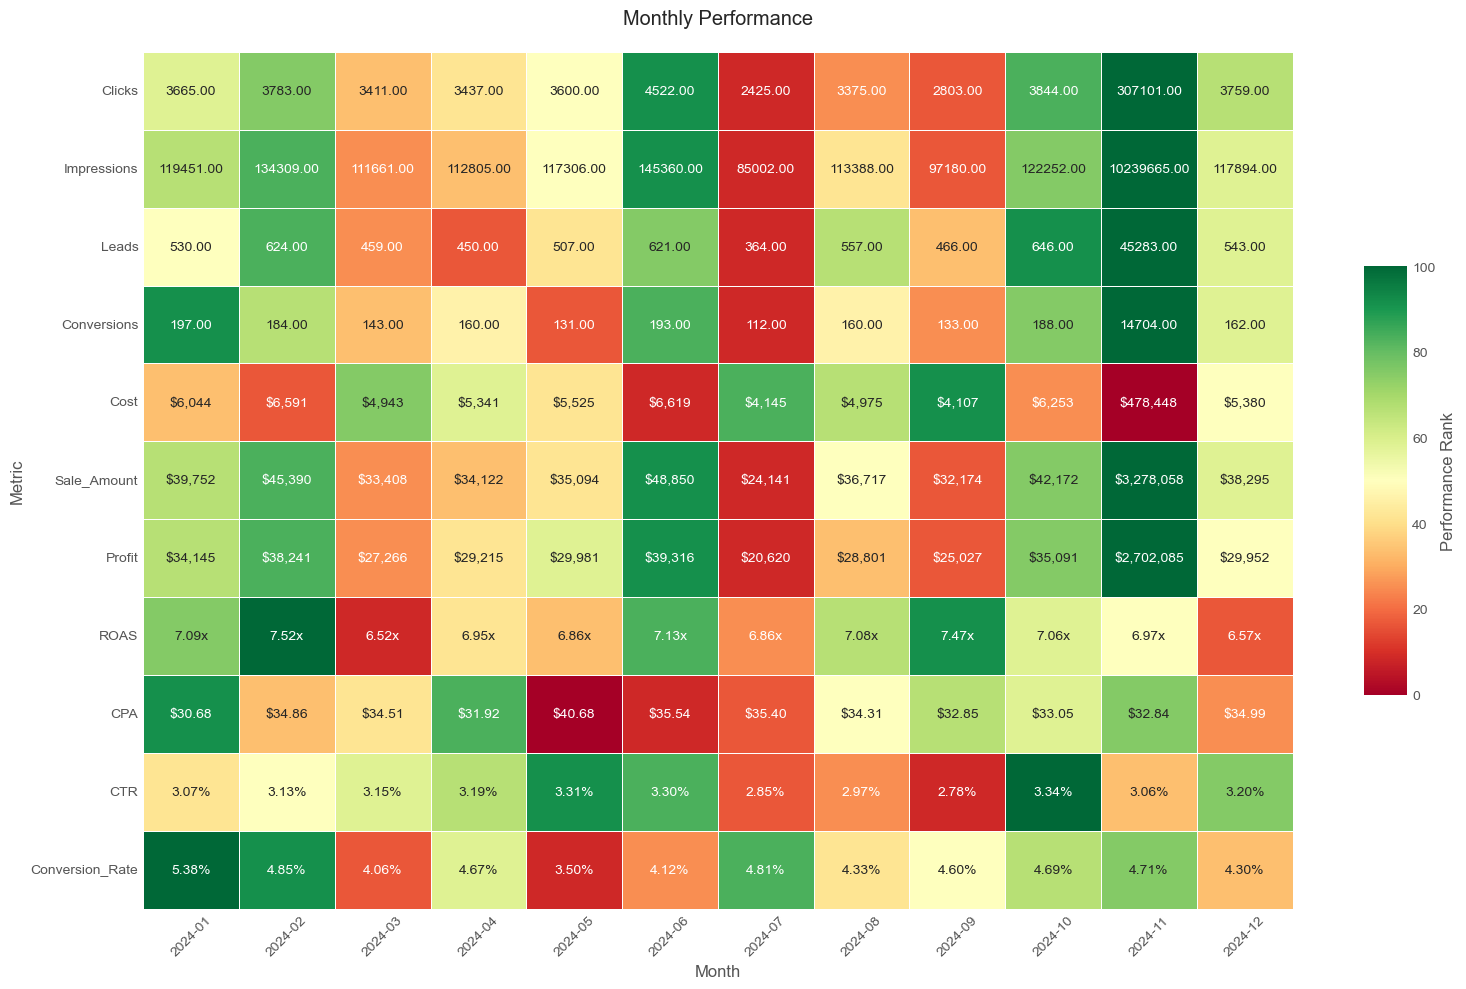


--- Generating Cost, Sale Amount, and Profit Trend Visualization ---


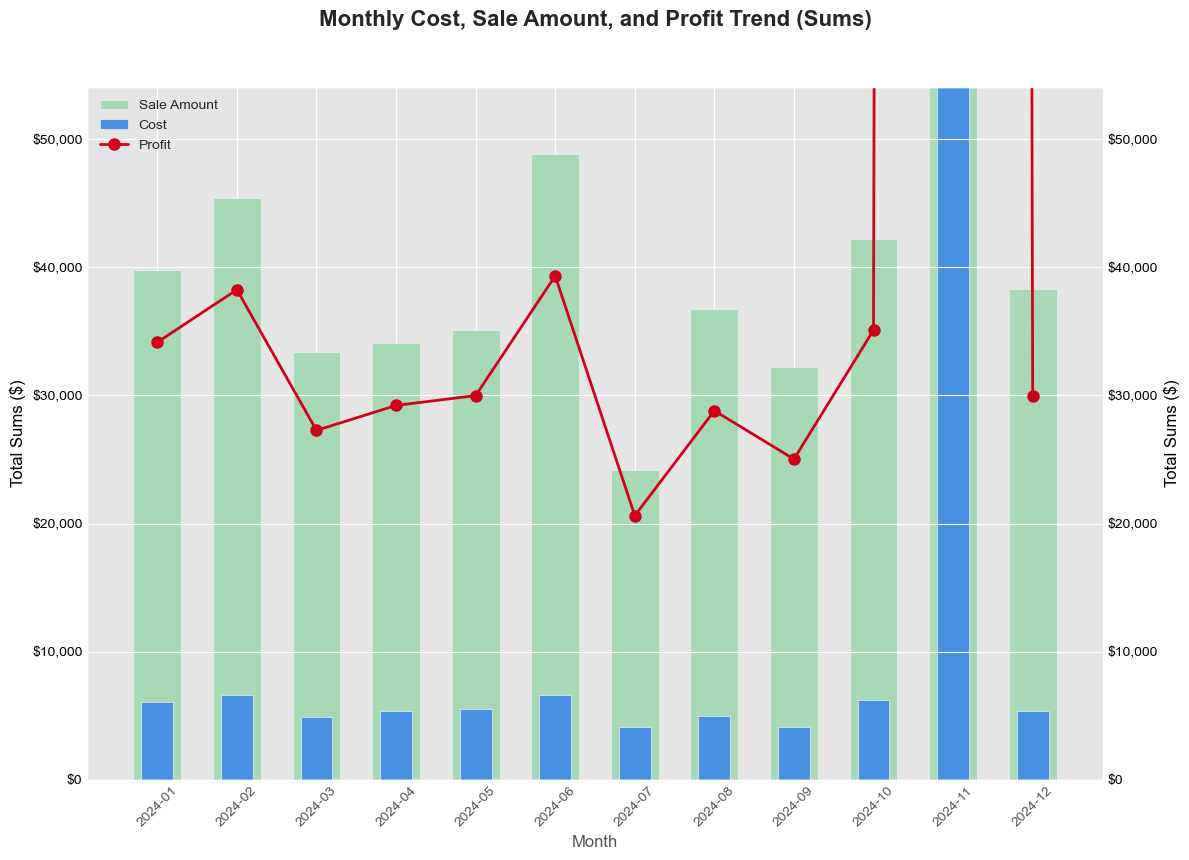


--- Generating Heat Map with Continuous Gradient ---


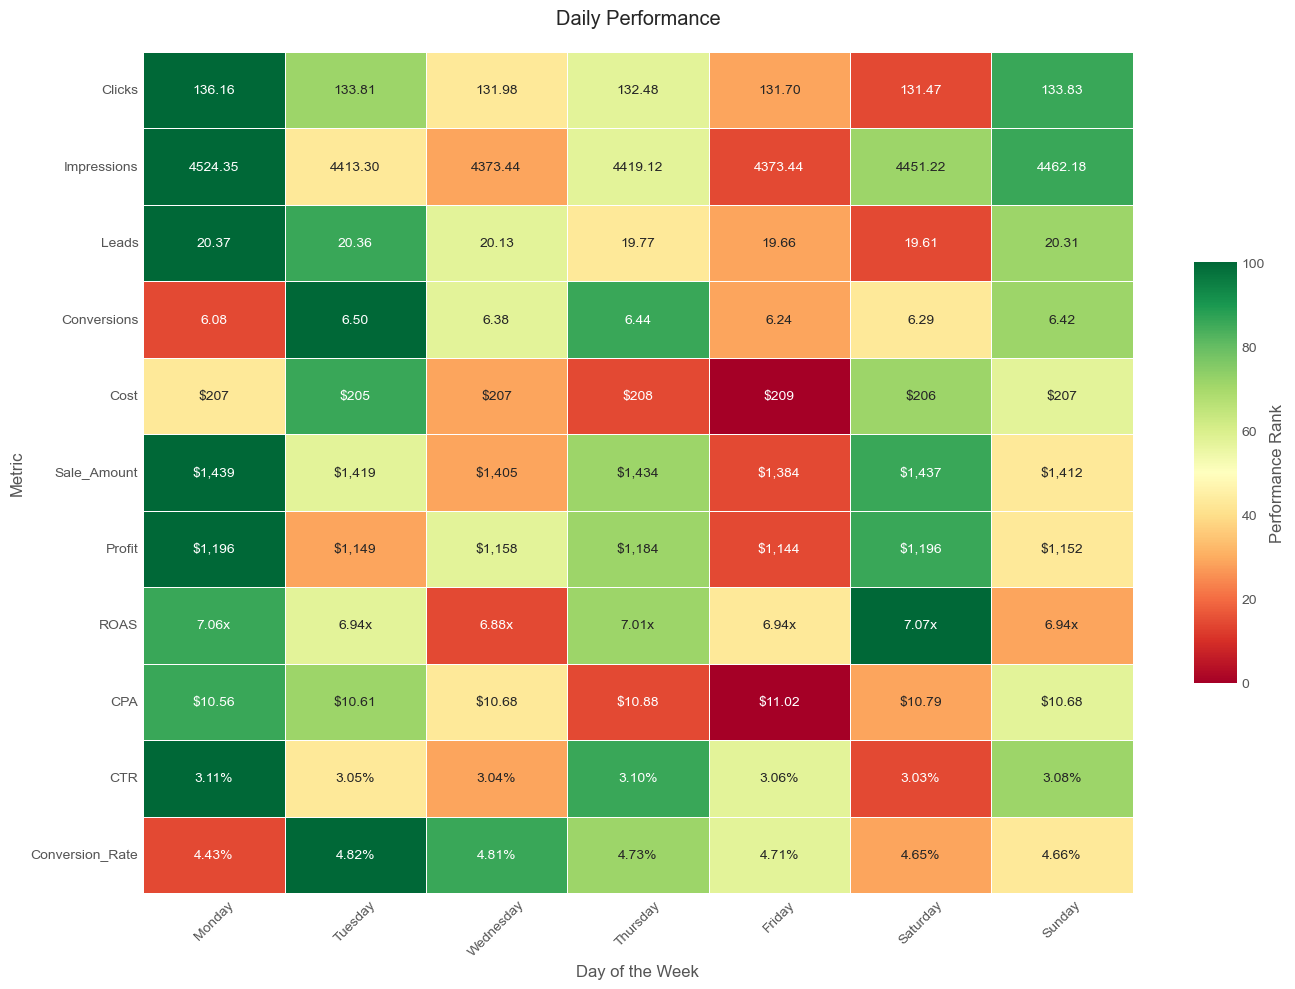

In [87]:
import matplotlib.pyplot as plt

def calculate_monthly_metrics(df_data, report_period, overall_sums):
    """
    Calculates performance metrics for a given DataFrame slice and returns them as a dictionary.

    Args:
        df_data (pd.DataFrame): The DataFrame containing the performance data.
        report_period (str): The title for the report period (e.g., 'January 2024').
        overall_sums (dict): A dictionary of total sums for each metric across all data.

    Returns:
        dict: A dictionary containing the report title, sums, averages, and weighted metrics.
    """
    
    # Check if df_data is empty
    if df_data.empty:
        return {'period': report_period, 'error': 'No data available'}

    # Columns for which we want sums and averages
    sum_and_avg_cols = ['Clicks', 'Impressions', 'Leads', 'Conversions', 'Cost', 'Sale_Amount', 'Profit'] 
    numerical_cols_exist = [col for col in sum_and_avg_cols if col in df_data.columns]
    
    # Calculate sums and means for the given data slice
    monthly_sum_results = df_data[numerical_cols_exist].sum()
    monthly_avg_results = df_data[numerical_cols_exist].mean()
    
    # Prepare the dictionary to return
    metrics = {
        'period': report_period,
        'sums': monthly_sum_results.to_dict(),
        'avgs': monthly_avg_results.to_dict(),
        'weighted': {},
        'percentage_of_total': {}
    }
    
    # Calculate and store percentage of overall sum
    for col in numerical_cols_exist:
        if overall_sums.get(col) and overall_sums[col] > 0:
            metrics['percentage_of_total'][col] = monthly_sum_results.get(col, 0) / overall_sums[col]
        else:
            metrics['percentage_of_total'][col] = 0

    # Calculate and store accurate weighted averages
    # CTR (Clicks/Impressions)
    if 'Clicks' in df_data.columns and 'Impressions' in df_data.columns:
        df_for_ctr = df_data[(df_data['Clicks'] > 0) & (df_data['Impressions'] > 0)]
        if not df_for_ctr.empty and df_for_ctr['Impressions'].sum() > 0:
            metrics['weighted']['CTR'] = df_for_ctr['Clicks'].sum() / df_for_ctr['Impressions'].sum()
        else:
            metrics['weighted']['CTR'] = None

    # Conversion Rate (Conversions/Clicks)
    if 'Conversions' in df_data.columns and 'Clicks' in df_data.columns:
        df_for_conversions = df_data[(df_data['Conversions'] > 0) & (df_data['Clicks'] > 0)]
        if not df_for_conversions.empty and df_for_conversions['Clicks'].sum() > 0:
            metrics['weighted']['Conversion_Rate'] = df_for_conversions['Conversions'].sum() / df_for_conversions['Clicks'].sum()
        else:
            metrics['weighted']['Conversion_Rate'] = None

    # ROAS (Sale_Amount/Cost)
    if 'Sale_Amount' in df_data.columns and 'Cost' in df_data.columns:
        df_for_roas = df_data[(df_data['Sale_Amount'] > 0) & (df_data['Cost'] > 0)]
        if not df_for_roas.empty and df_for_roas['Cost'].sum() > 0:
            metrics['weighted']['ROAS'] = df_for_roas['Sale_Amount'].sum() / df_for_roas['Cost'].sum()
        else:
            metrics['weighted']['ROAS'] = None

    # CPA (Cost/Conversions)
    if 'Conversions' in df_data.columns and 'Cost' in df_data.columns:
        df_for_cpa = df_data[(df_data['Conversions'] > 0) & (df_data['Cost'] > 0)]
        if not df_for_cpa.empty and df_for_cpa['Cost'].sum() > 0:
            metrics['weighted']['CPA'] = df_for_cpa['Cost'].sum() / df_for_cpa['Conversions'].sum()
        else:
            metrics['weighted']['CPA'] = None

    return metrics

def print_report(metrics):
    """
    Prints a formatted report from a metrics dictionary.
    """
    if 'error' in metrics:
        print(f"\n===== Report for {metrics['period']} =====")
        print(metrics['error'])
        return

    print(f"\n===== Report for {metrics['period']} =====")
    print("\n--- Summary of Data ---")

    for col in metrics['sums']:
        sum_val = metrics['sums'][col]
        avg_val = metrics['avgs'][col]
        percent_of_total = metrics['percentage_of_total'][col]
        
        # Use a fixed width for the sum value to ensure consistent alignment of the percentage
        if col in ['Cost', 'Sale_Amount', 'Profit']:
            sum_part = f"(Sum): ${sum_val:,.2f}"
            avg_part = f"(Avg): ${avg_val:,.2f}"
        else:
            sum_part = f"(Sum): {int(np.floor(sum_val)):,}"
            avg_part = f"(Avg): {int(np.floor(avg_val)):,}"
        
        # The sum line includes the percentage, which is now aligned
        print(f"{col:<30} {sum_part:<20} ({percent_of_total:.2%})")
        # The average line is printed on the next line without a percentage
        print(f"{col:<30} {avg_part}")
        print("-" * 45)

    # Calculate and print the percentage difference right above the weighted averages
    sale_percent = metrics['percentage_of_total'].get('Sale_Amount', 0)
    cost_percent = metrics['percentage_of_total'].get('Cost', 0)
    percent_difference = sale_percent - cost_percent
    
    print(f"\n--- Percent Difference (Sale % - Cost %) ---")
    print(f"{'Percentage Difference:':<10} {percent_difference:.2%}")
    
    print("\n--- Accurate Weighted Averages for Key Metrics ---")
    
    if 'CTR' in metrics['weighted'] and metrics['weighted']['CTR'] is not None:
        print(f"{'CTR (Clicks/Impressions)':<40}: {metrics['weighted']['CTR']:.2%}")
    else:
        print(f"{'CTR (Clicks/Impressions)':<40}: Not enough data to calculate.")
        
    if 'Conversion_Rate' in metrics['weighted'] and metrics['weighted']['Conversion_Rate'] is not None:
        print(f"{'Conversion Rate (Conversions/Clicks)':<40}: {metrics['weighted']['Conversion_Rate']:.2%}")
    else:
        print(f"{'Conversion Rate (Conversions/Clicks)':<40}: Not enough data to calculate.")
    
    if 'ROAS' in metrics['weighted'] and metrics['weighted']['ROAS'] is not None:
        print(f"{'ROAS (Sale_Amount/Cost)':<40}: {metrics['weighted']['ROAS']:,.2f}x")
    else:
        print(f"{'ROAS (Sale_Amount/Cost)':<40}: Not enough data to calculate.")

    if 'CPA' in metrics['weighted'] and metrics['weighted']['CPA'] is not None:
        print(f"{'CPA (Cost/Conversions)':<40}: ${metrics['weighted']['CPA']:,.2f}") 
    else:
        print(f"{'CPA (Cost/Conversions)':<40}: Not enough data to calculate.")

    print("\n\n\n")



def generate_all_data_report(df, overall_sums):
    """
    Generates and prints a report for the entire dataset.

    Args:
        df: The complete dataset.
        overall_sums: Sums for the entire dataset.
    """
    print("\n--- Report for the entire dataset ---")
    metrics = calculate_monthly_metrics(df, report_period='All Data', overall_sums=overall_sums)
    print_report(metrics)


def generate_one_month_report(df, specific_month, overall_sums):
    """
    Generates and prints a report for a specific month.

    Args:
        df: The complete dataset.
        specific_month: The month to report on (e.g., '2024-11').
        overall_sums: Sums for the entire dataset.
    """
    print(f"\n--- Report for a specific month ({specific_month}) ---")
    df_specific_month = df[df['Month_Name'] == specific_month]
    if not df_specific_month.empty:
        metrics = calculate_monthly_metrics(df_specific_month, report_period=specific_month, overall_sums=overall_sums)
        print_report(metrics)
    else:
        print(f"No data available for the month: {specific_month}.")


def generate_all_monthly_reports(df, overall_sums):
    """
    Generates and prints a report for each month in the dataset.

    Args:
        df: The complete dataset.
        overall_sums: Sums for the entire dataset.

    Returns:
        A list of dictionaries, where each dictionary contains the metrics for a single month.
    """
    print("\n--- Reports for all months ---")
    all_monthly_reports = []
    # Using sorted keys to ensure a consistent report order
    for month in sorted(df['Month_Name'].unique()):
        month_df = df[df['Month_Name'] == month]
        metrics = calculate_monthly_metrics(month_df, report_period=month, overall_sums=overall_sums)
        all_monthly_reports.append(metrics)
        print_report(metrics)
    return all_monthly_reports


def find_best_performing_month(all_monthly_reports):
    """
    Analyzes all monthly reports to find and print the best performing month
    for various metrics.

    Args:
        all_monthly_reports: A list of dictionaries containing metrics for all months.
    """
    if not all_monthly_reports:
        print("\nNo monthly reports available to determine best month.")
        return

    print("\n\n--- Best Performing Month Report ---")
    best_months = {}

    # Best month for sums (higher is better, except for Cost)
    for metric in ['Clicks', 'Impressions', 'Leads', 'Conversions', 'Sale_Amount', 'Profit']:
        best_months[metric] = max(all_monthly_reports, key=lambda x: x['sums'][metric] if 'sums' in x and x['sums'].get(metric) is not None else -1)
        
    # Best month for Cost (lower is better)
    best_months['Cost'] = min(all_monthly_reports, key=lambda x: x['sums']['Cost'] if 'sums' in x and x['sums'].get('Cost') is not None else float('inf'))

    # Best month for CPA (lower is better)
    best_months['CPA'] = min(all_monthly_reports, key=lambda x: x['weighted']['CPA'] if 'weighted' in x and x['weighted'].get('CPA') is not None else float('inf'))

    # Best month for weighted metrics (higher is better)
    for metric in ['CTR', 'Conversion_Rate', 'ROAS']:
        best_months[metric] = max(all_monthly_reports, key=lambda x: x['weighted'][metric] if 'weighted' in x and x['weighted'].get(metric) is not None else -1)

    # Find the month with the best cost vs. return
    best_cost_vs_return = max(all_monthly_reports, key=lambda x: (x['percentage_of_total'].get('Sale_Amount', 0) - x['percentage_of_total'].get('Cost', 0)) if 'percentage_of_total' in x else -1)
    best_months['Cost vs. Return'] = best_cost_vs_return

    # Print the results
    for metric, report in best_months.items():
        if 'error' in report:
            print(f"{metric:<30}: Not enough data to determine a best month.")
        elif metric == 'Cost vs. Return':
            sale_percent = report['percentage_of_total']['Sale_Amount']
            cost_percent = report['percentage_of_total']['Cost']
            percent_difference = sale_percent - cost_percent
            print(f"{'Cost vs. Return':<30}: {report['period']} with a difference of {percent_difference:.2%}")
        elif metric in ['CTR', 'Conversion_Rate', 'ROAS', 'CPA']:
            value = report['weighted'][metric]
            if value is not None:
                if metric == 'ROAS':
                    print(f"{metric:<30}: {report['period']} with a value of {value:,.2f}x")
                elif metric == 'CPA':
                    print(f"{metric:<30}: {report['period']} with a value of ${value:.2f}")
                else:
                    print(f"{metric:<30}: {report['period']} with a value of {value:.2%}")
            else:
                print(f"{metric:<30}: Not enough data to determine a best month.")
        else: # This else block now correctly handles all the sum-based metrics
            value = report['sums'][metric]
            if value is not None:
                if metric in ['Cost', 'Sale_Amount', 'Profit']:
                    print(f"{metric:<30}: {report['period']} with a sum of ${value:,.2f}")
                else:
                    print(f"{metric:<30}: {report['period']} with a sum of {value:,.0f}")
            else:
                print(f"{metric:<30}: Not enough data to determine a best month.")

# # --- ANSI color codes for terminal output ---
# GREEN = '\033[92m'
# YELLOW = '\033[93m'
# RED = '\033[91m'
# ENDC = '\033[0m'

import seaborn as sns
from matplotlib.colors import ListedColormap



def generate_monthly_heatmap(all_monthly_reports, is_avg, avg_metric_names, weighted_metric_names):
    """
    Generates and displays a single heat map of monthly percentile ranks with a continuous color gradient.
    """
    print("\n--- Generating Heat Map with Continuous Gradient ---")

    if not all_monthly_reports:
        print("No monthly data available for visualization.")
        return

    # Extract all metric values for all months
    metric_data_values = {}
    
    # Process metrics from the 'avgs' or 'sums' dictionary
    if is_avg:
        mType = 'avgs'
    else: 
        mType = 'sums'
    for metric_name in avg_metric_names:
        values = []
        months = []
        for report in all_monthly_reports:
            value = report[mType].get(metric_name)
            if value is not None:
                values.append(value)
                months.append(report['period'])
        if values:
            metric_data_values[metric_name] = pd.Series(values, index=months)

    # Process metrics from the 'weighted' dictionary
    for metric_name in weighted_metric_names:
        values = []
        months = []
        for report in all_monthly_reports:
            value = report['weighted'].get(metric_name)
            if value is not None:
                values.append(value)
                months.append(report['period'])
        if values:
            metric_data_values[metric_name] = pd.Series(values, index=months)
    
    if not metric_data_values:
        print("No valid data found for the specified metrics. Cannot generate heat map.")
        return

    # Create a DataFrame from the collected series for the actual values
    df_values = pd.DataFrame(metric_data_values).T

    # Calculate percentile ranks (0-100) for each column to drive the coloring
    df_percentiles = df_values.rank(pct=True, axis=1) * 100

    # For metrics where lower is better (e.g., CPA, Cost), invert the percentile rank for coloring
    for metric in ['CPA', 'Cost']:
        if metric in df_percentiles.index:
            df_percentiles.loc[metric, :] = 100 - df_percentiles.loc[metric, :]
    
    # Increased the figure size to make the plot a bit wider
    plt.figure(figsize=(16, 10))

    # Function to format the annotation text
    def format_annotations(row, col):
        metric_name = row.name
        value = row[col]

        # Format CTR and Conversion_Rate as percentages
        if metric_name in ['CTR', 'Conversion_Rate']:
            return f'{value * 100:.2f}%'
        elif metric_name in ['Cost', 'Sale_Amount', 'Profit']:
            return f'${value:,.0f}'
        elif metric_name == 'CPA':
            return f'${value:.2f}'
        elif metric_name == 'ROAS':
            return f'{value:.2f}x'

        # Format integer values with commas
        if isinstance(value, (int, np.integer)) and value >= 1000:
            return f'{value:,.0f}'
    
        # Format float values with two decimal places for other metrics
        elif isinstance(value, (float, np.float64)):
            return f'{value:.2f}'
    
        return str(value)

    # Create a new DataFrame for annotations with formatted strings
    df_annotations = pd.DataFrame(
        [[format_annotations(row, col) for col in df_values.columns] for _, row in df_values.iterrows()],
        index=df_values.index,
        columns=df_values.columns
    )
    
    sns.heatmap(
        data=df_percentiles, # Use percentiles for the coloring
        annot=df_annotations, # Use formatted values for the text
        fmt='', # No default formatting, we're using our own
        cmap='RdYlGn', # Use a continuous red-yellow-green colormap
        linewidths=.5,
        linecolor='white',
        cbar_kws={
            'shrink': 0.5,
            'aspect': 10,
            'label': 'Performance Rank'
        }
    )
    
    plt.title('Monthly Performance', pad=20)
    plt.ylabel('Metric')
    plt.xlabel('Month')
    plt.yticks(rotation=0)
    plt.xticks(rotation=45)

    # Display the plot
    plt.tight_layout()
    plt.show()





def calculate_daily_metrics(day_df, is_avg, report_period):
    """
    Calculates various marketing metrics for a given day, using the average
    for simple metrics and a robust, filtered sum-based calculation for
    weighted metrics.

    Args:
        day_df (DataFrame): A DataFrame containing data for a specific day.
        report_period (str): The name of the day (e.g., 'Monday').

    Returns:
        dict: A dictionary of calculated metrics for the day.
    """
    metrics = {
        'Day': report_period,
        'Leads': 0,
        'Cost': 0,
        'Sale_Amount': 0,
        'Profit': 0,
        'Clicks': 0,
        'Impressions': 0,
        'Conversions': 0,
        'ROAS': 0,
        'CPA': 0,
        'CTR': 0,
        'Conversion_Rate': 0,
    }

    if not day_df.empty:
        # Calculate averages for simple metrics
        if is_avg:
            daily_averages = day_df.mean(numeric_only=True)
        else:
            daily_averages = day_df.sum(numeric_only=True)
        metrics['Leads'] = daily_averages.get('Leads', 0)
        metrics['Cost'] = daily_averages.get('Cost', 0)
        metrics['Sale_Amount'] = daily_averages.get('Sale_Amount', 0)
        metrics['Profit'] = daily_averages.get('Profit', 0)
        metrics['Clicks'] = daily_averages.get('Clicks', 0)
        metrics['Impressions'] = daily_averages.get('Impressions', 0)
        metrics['Conversions'] = daily_averages.get('Conversions', 0)

        # Calculate weighted averages by first filtering out zero-value rows
        # CTR (Clicks/Impressions)
        df_for_ctr = day_df[(day_df['Clicks'] > 0) & (day_df['Impressions'] > 0)]
        if not df_for_ctr.empty and df_for_ctr['Impressions'].sum() > 0:
            metrics['CTR'] = df_for_ctr['Clicks'].sum() / df_for_ctr['Impressions'].sum()

        # Conversion Rate (Conversions/Clicks)
        df_for_conversions = day_df[(day_df['Conversions'] > 0) & (day_df['Clicks'] > 0)]
        if not df_for_conversions.empty and df_for_conversions['Clicks'].sum() > 0:
            metrics['Conversion_Rate'] = df_for_conversions['Conversions'].sum() / df_for_conversions['Clicks'].sum()

        # ROAS (Sale_Amount/Cost)
        df_for_roas = day_df[(day_df['Sale_Amount'] > 0) & (day_df['Cost'] > 0)]
        if not df_for_roas.empty and df_for_roas['Cost'].sum() > 0:
            metrics['ROAS'] = df_for_roas['Sale_Amount'].sum() / df_for_roas['Cost'].sum()

        # CPA (Cost/Leads)
        df_for_cpa = day_df[(day_df['Cost'] > 0) & (day_df['Leads'] > 0)]
        if not df_for_cpa.empty and df_for_cpa['Leads'].sum() > 0:
            metrics['CPA'] = df_for_cpa['Cost'].sum() / df_for_cpa['Leads'].sum()

    return metrics

def generate_all_daily_reports(df, is_avg):
    """
    Generates a list of reports, one for each day of the week.

    Args:
        df (DataFrame): The main DataFrame.

    Returns:
        DataFrame: A DataFrame of all daily reports.
    """
    all_daily_reports = []
    # Define the order of days for the heatmap
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for day in day_order:
        day_df = df[df['Day_of_Week'] == day]
        metrics = calculate_daily_metrics(day_df, is_avg, report_period=day)
        all_daily_reports.append(metrics)

    return pd.DataFrame(all_daily_reports)

def generate_daily_percentile_heatmap(all_reports, sum_metrics, weighted_metrics):
    """
    Generates a heatmap of daily performance using percentile ranks for coloring
    and actual values for annotations.

    Args:
        all_reports (DataFrame): A DataFrame of daily metrics.
        sum_metrics (list): List of sum-based metric names (e.g., 'Leads').
        weighted_metrics (list): List of weighted metric names (e.g., 'ROAS').
    """
    print(f"\n--- Generating Heat Map with Continuous Gradient ---")

    if all_reports.empty:
        print("No daily data available for visualization.")
        return

    # Combine the metric lists for plotting
    metrics_to_plot = sum_metrics + weighted_metrics
    df_values = all_reports.set_index('Day')[metrics_to_plot].transpose()

    # Calculate percentile ranks (0-100) for each row to drive the coloring
    df_percentiles = df_values.rank(pct=True, axis=1) * 100

    # For metrics where a lower value is better, invert the percentile rank for coloring
    for metric in ['CPA', 'Cost']:
        if metric in df_percentiles.index:
            df_percentiles.loc[metric, :] = 100 - df_percentiles.loc[metric, :]

    # Function to format the annotation text
    def format_annotations(row, col):
        metric_name = row.name
        value = row[col]

        # Format percentages
        if metric_name in ['CTR', 'Conversion_Rate']:
            return f'{value * 100:.2f}%'
        # Format monetary values
        elif metric_name in ['Cost', 'Sale_Amount', 'Profit']:
            return f'${value:,.0f}'
        elif metric_name == 'CPA':
            return f'${value:.2f}'
        # Format ROAS
        elif metric_name == 'ROAS':
            return f'{value:.2f}x'
        # Format large integers with commas
        elif isinstance(value, (int, np.integer)) and value >= 1000:
            return f'{value:,.0f}'
        # Format float values with two decimal places
        elif isinstance(value, (float, np.float64)):
            return f'{value:.2f}'

        return str(value)

    # Create a new DataFrame for annotations with formatted strings
    df_annotations = pd.DataFrame(
        [[format_annotations(row, col) for col in df_values.columns] for _, row in df_values.iterrows()],
        index=df_values.index,
        columns=df_values.columns
    )

    # Plot the heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        data=df_percentiles,          # Use percentiles for the coloring
        annot=df_annotations,         # Use formatted values for the text
        fmt='',                       # No default formatting
        cmap='RdYlGn',                # Use a continuous red-yellow-green colormap
        linewidths=.5,
        linecolor='white',
        cbar_kws={
            'shrink': 0.5,
            'aspect': 10,
            'label': 'Performance Rank'
        }
    )

    plt.title('Daily Performance', pad=20)
    plt.ylabel('Metric')
    plt.xlabel('Day of the Week')
    plt.yticks(rotation=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


import matplotlib.ticker as mtick

def visualize_cost_profit_trend(all_monthly_reports, is_sum=True):
    """
    Creates a professional combined line and bar chart to visualize Cost and Profit trends over time.
    
    The visualization features Sale Amount and Cost as overlapping bar charts on the primary Y-axis,
    and Profit as a line chart on a secondary Y-axis. The scales of both Y-axes are aligned
    to the same minimum and maximum values for accurate visual comparison. The graph's y-axis
    is automatically zoomed in to provide better visibility of the majority of the data,
    even if it means cutting off a significant outlier. This version improves the visibility
    of small bar values.

    Args:
        all_monthly_reports (list): A list of dictionaries containing metrics for all months.
        is_sum (bool): A flag to determine if sums (True) or averages (False) should be used.
    """
    print("\n--- Generating Cost, Sale Amount, and Profit Trend Visualization ---")

    if not all_monthly_reports:
        print("No monthly data available for visualization.")
        return

    # Select the data type (sums or averages)
    metric_type = 'sums' if is_sum else 'avgs'
    
    # Extract month, cost, profit, and sale_amount data
    months = [report['period'] for report in all_monthly_reports]
    costs = [report[metric_type].get('Cost', 0) for report in all_monthly_reports]
    sale_amounts = [report[metric_type].get('Sale_Amount', 0) for report in all_monthly_reports]
    profits = [report[metric_type].get('Profit', 0) for report in all_monthly_reports]
    
    # Create the figure and the first set of axes
    fig, ax1 = plt.subplots(figsize=(12, 9))

    # --- Plotting the Bars (with improved visibility) ---
    # The 'Sale Amount' bar chart is plotted first to appear behind the 'Cost' bar chart
    ax1.bar(months, sale_amounts, color='#A8D9B6', label='Sale Amount', width=0.6)
    # The 'Cost' bar chart is plotted on top of the 'Sale Amount' bars for a stacked/overlapping look.
    # The color is made solid and the width is slightly smaller to ensure it's visible.
    ax1.bar(months, costs, color='#4A90E2', label='Cost', width=0.4)
    
    # --- Configuring the Primary Y-Axis (for bars) ---
    ax1.set_xlabel('Month', fontsize=12)
    ax1.set_ylabel(f'Total {metric_type.capitalize()} ($)', color='black', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)

    # --- Creating and Plotting on the Secondary Y-Axis (for profit line) ---
    ax2 = ax1.twinx()
    # Plot the profit as a line chart with markers
    ax2.plot(months, profits, color='#D0021B', marker='o', linestyle='-', linewidth=2, label='Profit', markersize=8)
    ax2.set_ylabel(f'Total {metric_type.capitalize()} ($)', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

    # --- Aligning and zooming the Y-axes ---
    all_data = np.concatenate([costs, sale_amounts, profits])
    
    # Sort the absolute values of all data points in descending order
    sorted_abs_data = np.sort(np.abs(all_data))
    
    # The largest value is the outlier, so we find the second largest value to set the upper limit.
    # We add a small buffer to the second largest value. If there's only one point, use the max.
    if len(sorted_abs_data) > 1:
        # Corrected the multiplier to provide a buffer instead of a restrictive limit
        y_max = sorted_abs_data[-2] * 0.02 # 0.02 for a zoom in effect, 1.3 to see the top of the outlier
    else:
        y_max = sorted_abs_data[-1] if len(sorted_abs_data) > 0 else 1000
    
    y_min = 0
    
    # Set the same y-axis limits for both axes
    ax1.set_ylim(y_min * 1.1, y_max)
    ax2.set_ylim(y_min * 1.1, y_max)

    # --- Adding Title and Legends ---
    title_text = f"Monthly Cost, Sale Amount, and Profit Trend ({metric_type.capitalize()})"
    fig.suptitle(title_text, fontsize=16, fontweight='bold')

    # Combine the legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=10)

    # Adjust layout to make room for the title
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def showTotal_AdCounts(df, group_by_column):
    """
    Creates a bar graph of total 'Ad_ID' counts with a "zoom-in" effect,
    and handles potential layout issues with rotated labels.

    Args:
        df (pd.DataFrame): The input DataFrame.
        group_by_column (str): The column to group by, e.g., 'Month_Name' or 'Day_of_Week'.
    """
    if group_by_column not in df.columns:
        raise ValueError(f"Column '{group_by_column}' not found in the DataFrame.")

    ad_counts = df.groupby(group_by_column)['Ad_ID'].count()

    if ad_counts.empty:
        print(f"No data to plot for group '{group_by_column}'.")
        return

    # --- Zoom-in Logic ---
    sorted_counts = sorted(ad_counts)
    y_limit = None
    if len(sorted_counts) > 1:
        y_limit = sorted_counts[-2] * 1.05 # 5% above the second-highest bar
    elif len(sorted_counts) == 1:
        y_limit = sorted_counts[0] * 1.10 # 10% above the single bar

    max_count = ad_counts.max()
    bar_colors = ['forestgreen' if count == max_count else '#C0C0C0' for count in ad_counts]

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 6))
    ad_counts.plot(kind='bar', color=bar_colors, ax=ax)

    if y_limit is not None:
        ax.set_ylim(0, y_limit)

    for i, count in enumerate(ad_counts):
        if y_limit is None or count <= y_limit:
            ax.text(i, count, str(count), ha='center', va='bottom', fontsize=9)

    plt.title(f"Total Ad Counts by {group_by_column.replace('_', ' ').title()} (Zoomed)", fontsize=14)
    plt.xlabel(f"{group_by_column.replace('_', ' ').title()}", fontsize=12)
    plt.ylabel("Total Ad Counts", fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # --- FIX FOR THE USER WARNING ---
    # This gives more room at the bottom for the rotated x-axis labels.
    plt.subplots_adjust(bottom=0.25)
    
    plt.show()



#'Month_Name' column for grouping
df['Month_Name'] = df['Ad_Date'].dt.to_period('M').astype(str)

# Generates a bar chart to see the total number of ads ran each month
showTotal_AdCounts(df, 'Month_Name')

# Calculate the overall sums for weighted calculations
overall_sums = {col: df[col].sum() for col in ['Clicks', 'Impressions', 'Leads', 'Conversions', 'Cost', 'Sale_Amount', 'Profit'] if col in df.columns}
# Define the lists of metrics to be visualized
average_metrics = ['Clicks', 'Impressions', 'Leads', 'Conversions', 'Cost', 'Sale_Amount', 'Profit']
weighted_metrics = ['ROAS', 'CPA', 'CTR', 'Conversion_Rate']


# # Option 1: All data
generate_all_data_report(df, overall_sums)

# # Option 2: One month
# generate_one_month_report(df, '2024-11', overall_sums)

# Option 3: All months
all_reports = generate_all_monthly_reports(df, overall_sums)

# Report of best performing month by category
find_best_performing_month(all_reports)

# # Generate the monthly reports and the heatmap for all metrics for months 
# all_monthly_reports = generate_all_monthly_reports(df, overall_sums)
generate_monthly_heatmap(all_reports, False, average_metrics, weighted_metrics) 

# Generates a line/bar graph for cost/profit
visualize_cost_profit_trend(all_monthly_reports, is_sum=True)

# # data setup for day of week analysis
df['Ad_Date'] = pd.to_datetime(df['Ad_Date'])
df['Day_of_Week'] = df['Ad_Date'].dt.day_name() 
# Generates a heatmap for best performing days
all_reports2 = generate_all_daily_reports(df, True) 
generate_daily_percentile_heatmap(all_reports2, average_metrics, weighted_metrics)



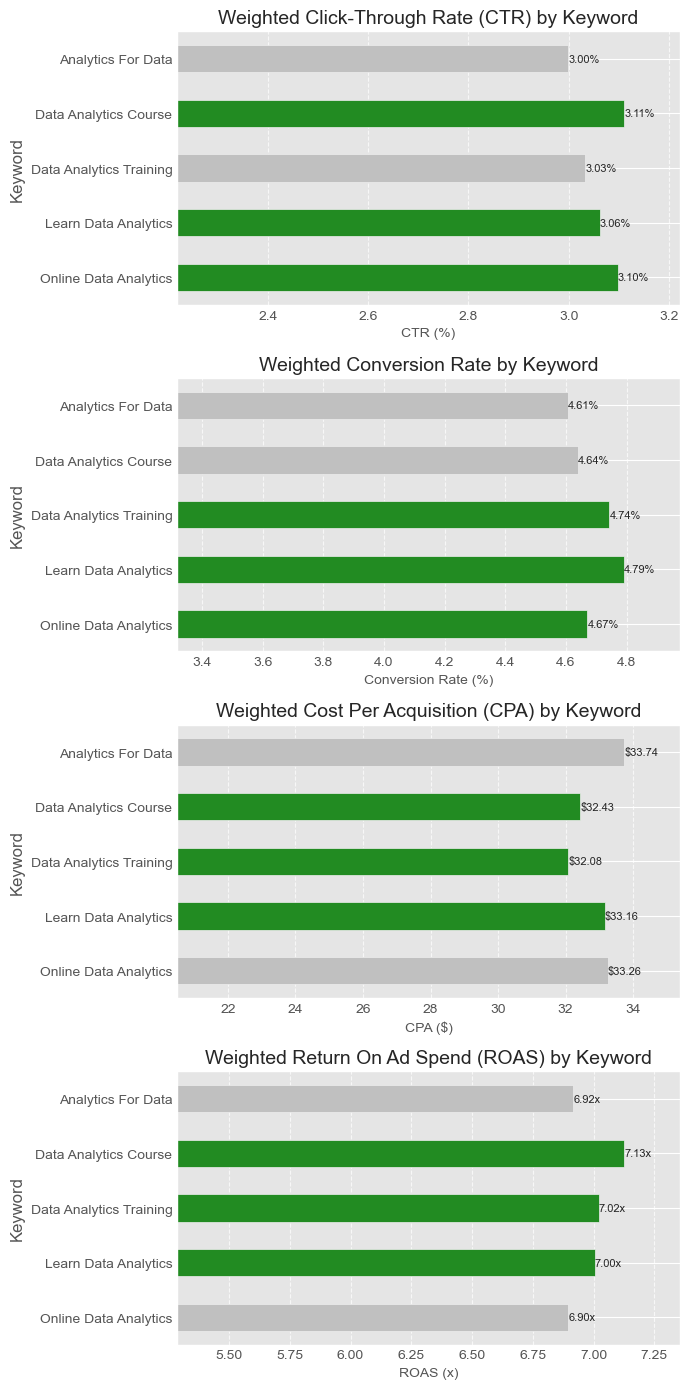

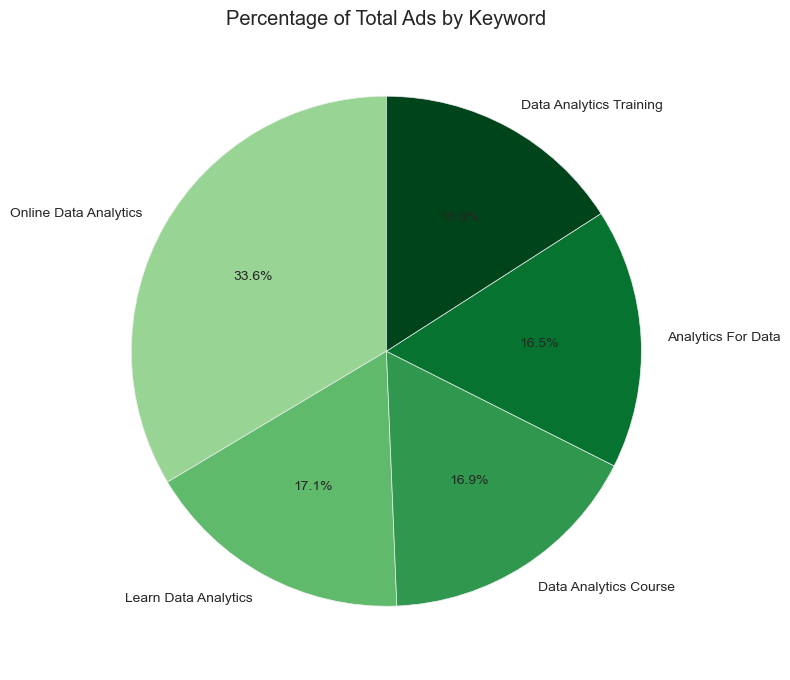


--- Funnel Analysis Summary by Keyword ---
Green: Best Performer
Blue: Second-Best Performer
Red: Third-Best Performer

--- 'Analytics For Data' Performance ---
Percentage of Total Ads: 16.50%
Weighted CTR: 3.00%
Weighted Conversion Rate: 4.61%
Weighted CPA: $33.74
Weighted ROAS: 6.92x

--- 'Data Analytics Course' Performance ---
Percentage of Total Ads: 16.92%
Weighted CTR: 3.11%
Weighted Conversion Rate: 4.64%
Weighted CPA: $32.43
Weighted ROAS: 7.13x

--- 'Data Analytics Training' Performance ---
Percentage of Total Ads: 15.92%
Weighted CTR: 3.03%
Weighted Conversion Rate: 4.74%
Weighted CPA: $32.08
Weighted ROAS: 7.02x

--- 'Learn Data Analytics' Performance ---
Percentage of Total Ads: 17.08%
Weighted CTR: 3.06%
Weighted Conversion Rate: 4.79%
Weighted CPA: $33.16
Weighted ROAS: 7.00x

--- 'Online Data Analytics' Performance ---
Percentage of Total Ads: 33.58%
Weighted CTR: 3.10%
Weighted Conversion Rate: 4.67%
Weighted CPA: $33.26
Weighted ROAS: 6.90x


In [59]:
import matplotlib.pyplot as plt

def analyze_performance_by_category(df, category_column):
    """
    Performs a comprehensive funnel analysis (CTR, Conversion Rate, CPA, ROAS)
    and visualizes the results for a specified categorical column.

    Args:
        df (pd.DataFrame): The input DataFrame containing ad performance data.
                            Expected columns: 'Clicks', 'Impressions', 'Conversions',
                            'Cost', 'Sale_Amount', 'Calculated_CTR', and the category_column.
        category_column (str): The name of the column to group by for analysis
                                (e.g., 'Device', 'keyword', 'campaign_name').
    """

    # print(f"\n--- Starting Funnel Analysis for '{category_column}' ---")

    # Data Validation and Preparation
    required_cols = ['Clicks', 'Impressions', 'Conversions', 'Cost', 'Sale_Amount']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Error: Missing required columns in DataFrame: {', '.join(missing_cols)}")
        return
    if category_column not in df.columns:
        print(f"Error: Category column '{category_column}' not found in DataFrame.")
        return

    # Fill NaNs with 0 for robustness in numerical columns
    df[required_cols] = df[required_cols].fillna(0)

    # Group data by the specified category and calculate all funnel metrics
    category_funnel_metrics = df.groupby(category_column).agg(
        Total_Clicks=('Clicks', 'sum'),
        Total_Impressions=('Impressions', 'sum'),
        Total_Conversions=('Conversions', 'sum'),
        Total_Cost=('Cost', 'sum'),
        Total_Sale_Amount=('Sale_Amount', 'sum'),
        Total_Ads=(category_column, 'count') # Count of ads (rows) for each category
    )

    # 1. Calculate Weighted CTR (Clicks / Impressions)
    # Create a temporary DataFrame with only the relevant rows (where both Clicks and Impressions > 0)
    ctr_data = df[(df['Clicks'] > 0) & (df['Impressions'] > 0)]
    # Group this filtered data and sum the columns
    ctr_summary = ctr_data.groupby(category_column).agg(
        Valid_Clicks=('Clicks', 'sum'),
        Valid_Impressions=('Impressions', 'sum')
    )
    # Merge the results back into the main DataFrame and perform the calculation
    category_funnel_metrics['Weighted_CTR'] = np.where(
        category_funnel_metrics.index.isin(ctr_summary.index), # Check if the category is in the filtered summary
        ctr_summary['Valid_Clicks'] / ctr_summary['Valid_Impressions'],
        0
    )
    
    
    # 2. Calculate Weighted Conversion Rate (Conversions / Clicks)
    # Filter for rows where both Conversions and Clicks > 0
    conv_data = df[(df['Conversions'] > 0) & (df['Clicks'] > 0)]
    conv_summary = conv_data.groupby(category_column).agg(
        Valid_Conversions=('Conversions', 'sum'),
        Valid_Clicks=('Clicks', 'sum')
    )
    category_funnel_metrics['Weighted_Conversion_Rate'] = np.where(
        category_funnel_metrics.index.isin(conv_summary.index),
        conv_summary['Valid_Conversions'] / conv_summary['Valid_Clicks'],
        0
    )
    
    
    # 3. Calculate Weighted CPA (Cost / Conversions)
    # Filter for rows where both Cost and Conversions > 0
    cpa_data = df[(df['Cost'] > 0) & (df['Conversions'] > 0)]
    cpa_summary = cpa_data.groupby(category_column).agg(
        Valid_Cost=('Cost', 'sum'),
        Valid_Conversions=('Conversions', 'sum')
    )
    category_funnel_metrics['Weighted_CPA'] = np.where(
        category_funnel_metrics.index.isin(cpa_summary.index),
        cpa_summary['Valid_Cost'] / cpa_summary['Valid_Conversions'],
        0
    )
    
    
    # 4. Calculate Weighted ROAS (Sale_Amount / Cost)
    # Filter for rows where both Sale_Amount and Cost > 0
    roas_data = df[(df['Sale_Amount'] > 0) & (df['Cost'] > 0)]
    roas_summary = roas_data.groupby(category_column).agg(
        Valid_Sale_Amount=('Sale_Amount', 'sum'),
        Valid_Cost=('Cost', 'sum')
    )
    category_funnel_metrics['Weighted_ROAS'] = np.where(
        category_funnel_metrics.index.isin(roas_summary.index),
        roas_summary['Valid_Sale_Amount'] / roas_summary['Valid_Cost'],
        0
    )


    # print(f"\nCalculated {category_column}-level funnel metrics (Weighted Averages):")
    # print(category_funnel_metrics[['Weighted_CTR', 'Weighted_Conversion_Rate', 'Weighted_CPA', 'Weighted_ROAS']])

    # Calculate overall total number of ads for percentage contribution
    overall_total_ads = df.shape[0]

    # Create bar charts for the funnel effect
    plt.style.use('ggplot')

    # Determine if we should use a horizontal layout
    num_categories = len(category_funnel_metrics.index)
    max_label_length = category_funnel_metrics.index.map(len).max() if not category_funnel_metrics.empty else 0
    is_horizontal = num_categories >= 5 or max_label_length > 10

    if is_horizontal:
        # Dynamic figure size for horizontal plots
        dynamic_fig_height = max(14, num_categories * 0.5) 
        fig, axes = plt.subplots(4, 1, figsize=(7, dynamic_fig_height))
    else:
        # Original figure size for vertical plots
        dynamic_fig_height = 12 + max(0, (num_categories - 3) * 0.8) 
        fig, axes = plt.subplots(4, 1, figsize=(8, dynamic_fig_height), sharex=False)

    # colors = ['skyblue', 'lightcoral', 'lightgreen', 'mediumpurple', 'lightsalmon', 'darkorange', 'teal', 'grey'] # Expanded colors for more categories
    # Colors for the bar charts
    BAR_COLOR_BEST = 'forestgreen'
    BAR_COLOR_OTHER = '#C0C0C0'
    
    def plot_metric(ax, data, title, ylabel, value_format, is_cpa=False):
        # Sort the data alphabetically by index (category name) for consistent plotting order
        data = data.sort_index(ascending=False)

        if data.empty:
            return

        num_categories = len(data)
        # Determine how many performers to highlight based on the number of categories
        n_performers_to_show = 3 if num_categories >= 5 else 1

        # --- Updated logic to find and highlight the top N performers with tie-breaking ---
        if is_cpa: # For CPA, lower is better, so we use nsmallest
            # Get the Nth smallest value, rounded to 2 decimal places
            rounded_threshold = round(data.nsmallest(n_performers_to_show).iloc[-1], 2)
            # Find all categories whose original value, when rounded, is less than or equal to this threshold
            top_performers = data[data.round(2) <= rounded_threshold].index.tolist()
        else: # For others, higher is better, so we use nlargest
            # Get the Nth largest value, rounded to 2 decimal places
            rounded_threshold = round(data.nlargest(n_performers_to_show).iloc[-1], 2)
            # Find all categories whose original value, when rounded, is greater than or equal to this threshold
            top_performers = data[data.round(2) >= rounded_threshold].index.tolist()

        # Create the bar colors list based on the top performers
        bar_colors = []
        for cat in data.index:
            if cat in top_performers:
                bar_colors.append(BAR_COLOR_BEST)
            else:
                bar_colors.append(BAR_COLOR_OTHER)


        # Use horizontal bar chart if is_horizontal is True
        if is_horizontal:
            bars = data.plot(kind='barh', ax=ax, color=bar_colors)
            ax.set_title(title, fontsize=14)
            ax.set_xlabel(ylabel, fontsize=10) # Swap x and y labels
            ax.set_ylabel(category_column.replace('_', ' ').title(), fontsize=12)
            ax.grid(axis='x', linestyle='--', alpha=0.7) # Change grid axis to x
            
            # Dynamic X-axis limits based on min/max
            data_min = data.min()
            data_max = data.max()
            if data_min == data_max:
                ax_min = max(0, data_min * 0.8) if data_min > 0 else 0
                ax_max = data_max * 1.2
            else:
                ax_min = max(0, data_min - (data_max - data_min) * 7)
                ax_max = data_max + (data_max - data_min)
            ax.set_xlim(ax_min, ax_max)
            
            # Add data labels inside the bars
            for bar in bars.patches:
                xval = bar.get_width()
                label_text = value_format.format(xval)
                ax.text(xval, bar.get_y() + bar.get_height()/2, label_text, 
                         va='center', ha='left', fontsize=8)

        else: # Vertical bar chart
            rotation_angle = 45 if max_label_length > 10 else 0
            bars = data.plot(kind='bar', ax=ax, color=bar_colors, rot=rotation_angle)
            ax.set_title(title, fontsize=14)
            ax.set_ylabel(ylabel, fontsize=10)
            ax.set_xlabel(category_column.replace('_', ' ').title(), fontsize=12)
            ax.grid(axis='y', linestyle='--', alpha=0.7)
            
            if rotation_angle != 0:
                plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
            
            # Adjust the y-axis limits for better visualization
            data_min = data.min()
            data_max = data.max()
            if data_min == data_max:
                ax_min = max(0, data_min * 0.8) if data_min > 0 else 0
                ax_max = data_max * 1.2
            else:
                data_range = data_max - data_min
                ax_min = max(0, data_min - data_range * 7)
                ax_max = data_max + data_range
            ax.set_ylim(ax_min, ax_max)
            
            
            # Add the value labels and asterisks to the bars
            for i, bar in enumerate(bars.patches):
                yval = bar.get_height()
                text_y_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
                va_align = 'bottom'
                
                label_text = value_format.format(yval)
                # The corrected line: check if the category for the current bar is in the top_performers list.
                if data.index[i] in top_performers:
                    label_text += '*'
            
                ax.text(bar.get_x() + bar.get_width()/2, yval + text_y_offset,
                        label_text, ha='center', va=va_align, fontsize=8)


    # Plot 1: Weighted CTR
    plot_metric(axes[0], category_funnel_metrics['Weighted_CTR'] * 100,
                f'Weighted Click-Through Rate (CTR) by {category_column.replace("_", " ").title()}', 'CTR (%)', '{:.2f}%')

    # Plot 2: Weighted Conversion Rate
    plot_metric(axes[1], category_funnel_metrics['Weighted_Conversion_Rate'] * 100,
                f'Weighted Conversion Rate by {category_column.replace("_", " ").title()}', 'Conversion Rate (%)', '{:.2f}%')

    # Plot 3: Weighted CPA
    plot_metric(axes[2], category_funnel_metrics['Weighted_CPA'],
                f'Weighted Cost Per Acquisition (CPA) by {category_column.replace("_", " ").title()}', 'CPA ($)', '${:,.2f}', is_cpa=True)

    # Plot 4: Weighted ROAS
    plot_metric(axes[3], category_funnel_metrics['Weighted_ROAS'],
                f'Weighted Return On Ad Spend (ROAS) by {category_column.replace("_", " ").title()}', 'ROAS (x)', '{:,.2f}x')

    plt.tight_layout()
    plt.show()


    
    # --- Pie Chart for Data Distribution ---
    # Calculate percentages of total ads for each category type
    category_ad_percentages = (df[category_column].value_counts(normalize=True) * 100)
    
    # Sort the percentages to apply the colormap effectively
    sorted_percentages = category_ad_percentages.sort_values(ascending=False)
    
    # Get a green colormap
    colors = plt.cm.Greens(np.linspace(0.4, 1, len(sorted_percentages)))

    # Create a new figure for the pie chart
    if is_horizontal: 
        plt.figure(figsize=(8,8))
    else:
        plt.figure(figsize=(5, 5))
    plt.pie(sorted_percentages, labels=sorted_percentages.index, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'Percentage of Total Ads by {category_column.replace("_", " ").title()}')
    plt.ylabel('') # Hide the default ylabel
    plt.tight_layout()
    plt.show()
    

    # --- ANSI Color Codes ---
    # Bright Green for best performer
    BRIGHT_GREEN = "\033[92m"
    # Bright Blue for second best performer
    BRIGHT_BLUE = "\033[94m"
    # Bright Red for third best performer
    BRIGHT_RED = "\033[91m"
    # Reset color to default
    RESET_COLOR = "\033[0m"

    print(f"\n--- Funnel Analysis Summary by {category_column.replace('_', ' ').title()} ---")
    print(f"{BRIGHT_GREEN}Green{RESET_COLOR}: Best Performer")
    print(f"{BRIGHT_BLUE}Blue{RESET_COLOR}: Second-Best Performer")
    print(f"{BRIGHT_RED}Red{RESET_COLOR}: Third-Best Performer")

    if not category_funnel_metrics.empty:
        # Calculate percentages of total ads for each category type
        category_ad_percentages = (df[category_column].value_counts(normalize=True) * 100)

        # Determine the best, second-best, and third-best performing categories for each metric
        def get_top_n_performers(series, n, ascending=False):
            sorted_series = series.sort_values(ascending=ascending)
            return sorted_series.index[:n].tolist()

        def get_bottom_n_performers(series, n, ascending=True):
            sorted_series = series.sort_values(ascending=ascending)
            return sorted_series.index[:n].tolist()

        top_ctr_categories = get_top_n_performers(category_funnel_metrics['Weighted_CTR'], 3, ascending=False)
        top_cr_categories = get_top_n_performers(category_funnel_metrics['Weighted_Conversion_Rate'], 3, ascending=False)
        top_roas_categories = get_top_n_performers(category_funnel_metrics['Weighted_ROAS'], 3, ascending=False)
        top_cpa_categories = get_bottom_n_performers(category_funnel_metrics['Weighted_CPA'], 3, ascending=True)
        top_ad_percent_categories = get_top_n_performers(category_ad_percentages, 3, ascending=False)


        for cat_type in category_funnel_metrics.index:
            print(f"\n--- '{cat_type}' Performance ---")
            
            # Percentage of Total Ads for this category type with color highlighting
            ads_percent = category_ad_percentages.get(cat_type, 0)
            ads_percent_display = f"{ads_percent:.2f}%"
            if cat_type == top_ad_percent_categories[0]:
                ads_percent_display = f"{BRIGHT_GREEN}{ads_percent_display}{RESET_COLOR}"
            elif len(top_ad_percent_categories) > 1 and cat_type == top_ad_percent_categories[1]:
                ads_percent_display = f"{BRIGHT_BLUE}{ads_percent_display}{RESET_COLOR}"
            elif len(top_ad_percent_categories) > 2 and cat_type == top_ad_percent_categories[2]:
                ads_percent_display = f"{BRIGHT_RED}{ads_percent_display}{RESET_COLOR}"
            print(f"Percentage of Total Ads: {ads_percent_display}")


            # Weighted Metrics with color indication of best/second best/third best performer
            ctr_value = category_funnel_metrics.loc[cat_type, 'Weighted_CTR']
            cr_value = category_funnel_metrics.loc[cat_type, 'Weighted_Conversion_Rate']
            cpa_value = category_funnel_metrics.loc[cat_type, 'Weighted_CPA']
            roas_value = category_funnel_metrics.loc[cat_type, 'Weighted_ROAS']

            # CTR
            ctr_display = f"{ctr_value:.2%}"
            if cat_type == top_ctr_categories[0]:
                ctr_display = f"{BRIGHT_GREEN}{ctr_display}{RESET_COLOR}"
            elif len(top_ctr_categories) > 1 and cat_type == top_ctr_categories[1]:
                ctr_display = f"{BRIGHT_BLUE}{ctr_display}{RESET_COLOR}"
            elif len(top_ctr_categories) > 2 and cat_type == top_ctr_categories[2]:
                ctr_display = f"{BRIGHT_RED}{ctr_display}{RESET_COLOR}"
            print(f"Weighted CTR: {ctr_display}")

            # Conversion Rate
            cr_display = f"{cr_value:.2%}"
            if cat_type == top_cr_categories[0]:
                cr_display = f"{BRIGHT_GREEN}{cr_display}{RESET_COLOR}"
            elif len(top_cr_categories) > 1 and cat_type == top_cr_categories[1]:
                cr_display = f"{BRIGHT_BLUE}{cr_display}{RESET_COLOR}"
            elif len(top_cr_categories) > 2 and cat_type == top_cr_categories[2]:
                cr_display = f"{BRIGHT_RED}{cr_display}{RESET_COLOR}"
            print(f"Weighted Conversion Rate: {cr_display}")

            # CPA
            cpa_display = f"${cpa_value:.2f}"
            if cat_type == top_cpa_categories[0]: # CPA is lower is better
                cpa_display = f"{BRIGHT_GREEN}{cpa_display}{RESET_COLOR}"
            elif len(top_cpa_categories) > 1 and cat_type == top_cpa_categories[1]:
                cpa_display = f"{BRIGHT_BLUE}{cpa_display}{RESET_COLOR}"
            elif len(top_cpa_categories) > 2 and cat_type == top_cpa_categories[2]:
                cpa_display = f"{BRIGHT_RED}{cpa_display}{RESET_COLOR}"
            print(f"Weighted CPA: {cpa_display}")

            # ROAS
            roas_display = f"{roas_value:.2f}x"
            if cat_type == top_roas_categories[0]:
                roas_display = f"{BRIGHT_GREEN}{roas_display}{RESET_COLOR}"
            elif len(top_roas_categories) > 1 and cat_type == top_roas_categories[1]:
                roas_display = f"{BRIGHT_BLUE}{roas_display}{RESET_COLOR}"
            elif len(top_roas_categories) > 2 and cat_type == top_roas_categories[2]:
                roas_display = f"{BRIGHT_RED}{roas_display}{RESET_COLOR}"
            print(f"Weighted ROAS: {roas_display}")
    else:
        print(f"No data available for analysis in '{category_column}'.")


# if you do it by Location you will get the weighted averages of CTR, Conversion Rates, CPA, ROAS - for the whole dataset
analyze_performance_by_category(df, 'Keyword')



--- Generating Industry Comparison Visualization ---


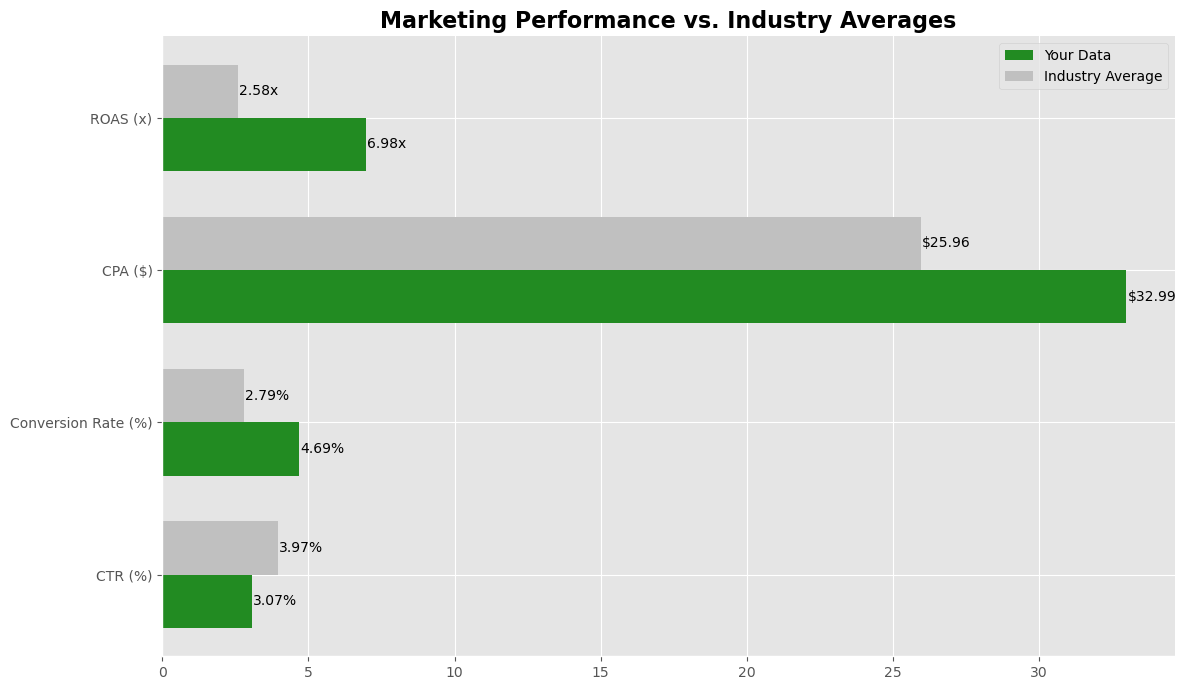


--- Generating ROAS by Average Cost Scatter Plot for Keyword ---


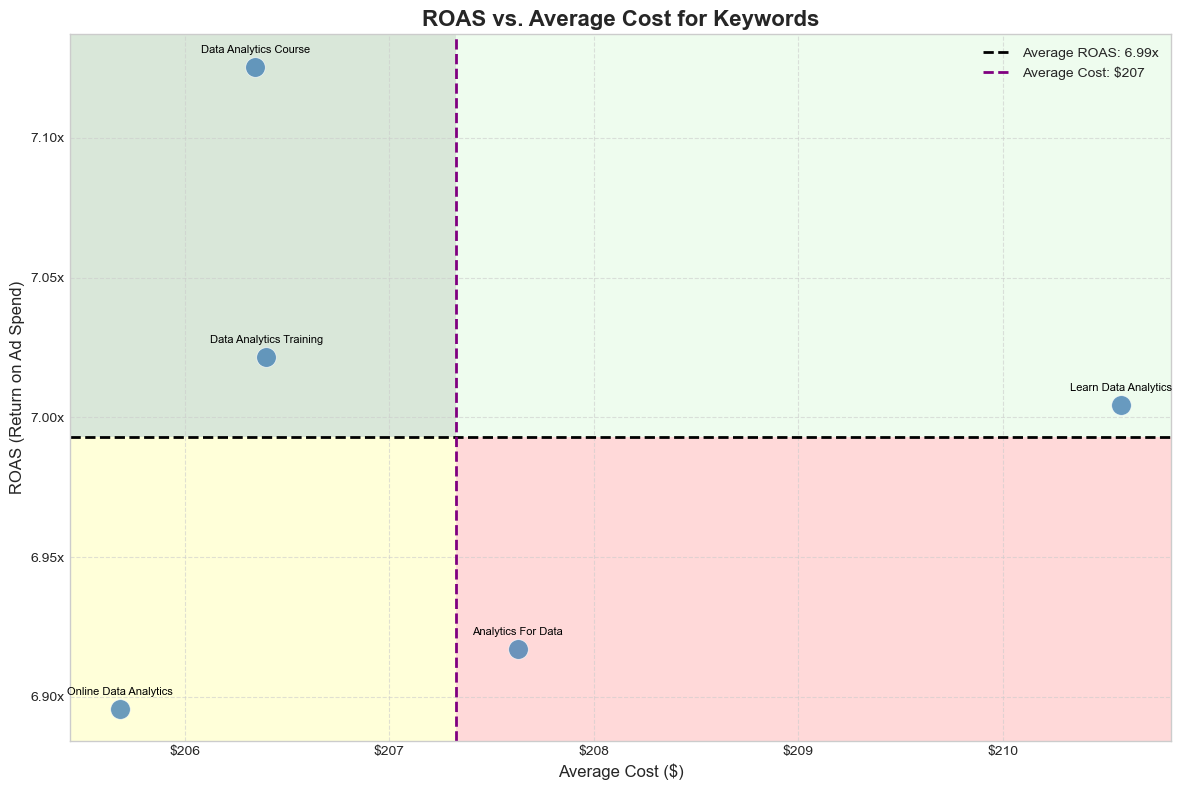

In [39]:
# using:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick
# import pandas as pd
# import numpy as np
import matplotlib.patches as patches


def visualize_roas_scatter_plot(df, group_by_column):
    """
    Creates a scatter plot to visualize the relationship between Average Cost and ROAS
    for each unique value in a specified column (e.g., 'Keyword' or 'Device').

    ROAS is calculated based on the total sums of Cost and Sale Amount for transactions
    where both values are greater than zero. The average cost for each group is
    plotted on the x-axis for display purposes.

    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        group_by_column (str): The column to group the data by, typically 'Keyword' or 'Device'.
    """
    print(f"\n--- Generating ROAS by Average Cost Scatter Plot for {group_by_column} ---")

    if not all(col in df.columns for col in ['Cost', 'Sale_Amount', group_by_column]):
        print(f"Required columns ('Cost', 'Sale_Amount', '{group_by_column}') not found in the DataFrame.")
        return

    # STEP 1: Calculate ROAS using the user's preferred logic
    # Filter the original dataframe to include only transactions with positive cost and sale amount
    roas_data = df[(df['Sale_Amount'] > 0) & (df['Cost'] > 0)]

    # Group this filtered data to get the total cost and sale amount for valid transactions
    roas_summary = roas_data.groupby(group_by_column).agg(
        Valid_Sale_Amount=('Sale_Amount', 'sum'),
        Valid_Cost=('Cost', 'sum')
    ).reset_index()

    # Calculate ROAS for each group based on the aggregated valid data
    roas_summary['ROAS'] = roas_summary['Valid_Sale_Amount'] / roas_summary['Valid_Cost']

    # STEP 2: Get the average cost for plotting purposes from the original dataframe
    mean_cost_summary = df.groupby(group_by_column).agg(
        Average_Cost=('Cost', 'mean')
    ).reset_index()

    # STEP 3: Combine the ROAS and average cost dataframes
    # Use a left merge to ensure all groups are included, even those with no valid ROAS data
    grouped_df = pd.merge(mean_cost_summary, roas_summary[[group_by_column, 'ROAS']], on=group_by_column, how='left')

    # For groups that had no valid ROAS data, the 'ROAS' column will be NaN. We fill these with 0.
    grouped_df['ROAS'] = grouped_df['ROAS'].fillna(0)
    
    # Rename the cost column for clarity in the plotting code
    grouped_df.rename(columns={'Average_Cost': 'Cost'}, inplace=True)
    
    # Calculate overall averages for the reference lines
    avg_cost = grouped_df['Cost'].mean()
    avg_roas = grouped_df['ROAS'].mean()

    # Create the scatter plot
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot the scatter points first so the axis limits are set automatically
    scatter = ax.scatter(
        grouped_df['Cost'],
        grouped_df['ROAS'],
        color='steelblue',
        s=200,
        alpha=0.8,
        edgecolors='w',
        linewidths=0.5
    )
    
    # Get the auto-scaled axis limits after plotting the data
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    # Add colored background quadrants using Rectangle patches
    ax.add_patch(patches.Rectangle((avg_cost, avg_roas), x_max - avg_cost, y_max - avg_roas, facecolor='lightgreen', alpha=0.15, zorder=0))
    ax.add_patch(patches.Rectangle((x_min, avg_roas), avg_cost - x_min, y_max - avg_roas, facecolor='darkgreen', alpha=0.15, zorder=0))
    ax.add_patch(patches.Rectangle((avg_cost, y_min), x_max - avg_cost, avg_roas - y_min, facecolor='red', alpha=0.15, zorder=0))
    ax.add_patch(patches.Rectangle((x_min, y_min), avg_cost - x_min, avg_roas - y_min, facecolor='yellow', alpha=0.15, zorder=0))

    
    # Add labels and title
    ax.set_xlabel('Average Cost ($)', fontsize=12)
    ax.set_ylabel('ROAS (Return on Ad Spend)', fontsize=12)
    ax.set_title(f'ROAS vs. Average Cost for {group_by_column}s', fontsize=16, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add a horizontal line for average ROAS
    ax.axhline(y=avg_roas, color='black', linestyle='--', linewidth=2, label=f'Average ROAS: {avg_roas:.2f}x')
    
    # Add a vertical line for average Cost
    ax.axvline(x=avg_cost, color='purple', linestyle='--', linewidth=2, label=f'Average Cost: ${avg_cost:,.0f}')

    # Set full numbers with dollar sign for x-axis
    ax.get_xaxis().set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    
    # Add 'x' to the y-axis values
    ax.get_yaxis().set_major_formatter(mtick.StrMethodFormatter('{x:,.2f}x'))

    # Add annotations for each point
    for i, row in grouped_df.iterrows():
        ax.annotate(
            row[group_by_column],
            (row['Cost'], row['ROAS']),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=8,
            color='black'
        )
        
    ax.legend()
    plt.tight_layout()
    plt.show()


def compare_to_industry_averages(df, industry_averages):
    """
    Creates a grouped horizontal bar chart to compare your marketing metrics
    against specified industry averages.

    This function calculates CTR, Conversion Rate, CPA, and ROAS from the
    provided DataFrame and plots them next to the industry benchmarks for easy
    visual comparison. It now uses a more robust calculation method by filtering
    out invalid data rows (where denominator is zero) before aggregation.

    Args:
        df (pd.DataFrame): The DataFrame containing the marketing data. It must
                           include the columns 'Impressions', 'Clicks', 'Conversions',
                           'Cost', and 'Sale_Amount'.
        industry_averages (dict): A dictionary containing the industry average metrics.
                                  Expected keys are 'CTR', 'CVR', 'CPA', and 'ROAS'.
                                  CVR and CTR should be percentages (e.g., 2.79 for 2.79%).
                                  CPA and ROAS should be numerical values.
    """
    print("\n--- Generating Industry Comparison Visualization ---")

    # Ensure the necessary columns exist in the DataFrame
    required_columns = ['Impressions', 'Clicks', 'Conversions', 'Cost', 'Sale_Amount']
    if not all(col in df.columns for col in required_columns):
        print("Error: The DataFrame must contain the following columns: ", required_columns)
        return

    # --- Robust Metric Calculation (per your example) ---
    your_metrics = {}

    # Calculate CTR (only for rows with Clicks > 0 and Impressions > 0)
    ctr_data = df[(df['Clicks'] > 0) & (df['Impressions'] > 0)]
    total_clicks = ctr_data['Clicks'].sum()
    total_impressions = ctr_data['Impressions'].sum()
    your_metrics['CTR'] = (total_clicks / total_impressions) * 100 if total_impressions > 0 else 0

    # Calculate CVR (only for rows with Conversions > 0 and Clicks > 0)
    cvr_data = df[(df['Conversions'] > 0) & (df['Clicks'] > 0)]
    total_conversions_cvr = cvr_data['Conversions'].sum()
    total_clicks_cvr = cvr_data['Clicks'].sum()
    your_metrics['CVR'] = (total_conversions_cvr / total_clicks_cvr) * 100 if total_clicks_cvr > 0 else 0

    # Calculate CPA (only for rows with Cost > 0 and Conversions > 0)
    cpa_data = df[(df['Cost'] > 0) & (df['Conversions'] > 0)]
    total_cost_cpa = cpa_data['Cost'].sum()
    total_conversions_cpa = cpa_data['Conversions'].sum()
    your_metrics['CPA'] = total_cost_cpa / total_conversions_cpa if total_conversions_cpa > 0 else 0

    # Calculate ROAS (only for rows with Sale_Amount > 0 and Cost > 0)
    roas_data = df[(df['Sale_Amount'] > 0) & (df['Cost'] > 0)]
    total_sale_amount = roas_data['Sale_Amount'].sum()
    total_cost_roas = roas_data['Cost'].sum()
    your_metrics['ROAS'] = total_sale_amount / total_cost_roas if total_cost_roas > 0 else 0

    # --- Plotting Section ---
    if not all(key in industry_averages for key in ['CTR', 'CVR', 'CPA', 'ROAS']):
        print("Error: The industry_averages dictionary must contain keys 'CTR', 'CVR', 'CPA', and 'ROAS'.")
        return

    # Prepare data for plotting
    metrics_to_compare = ['CTR', 'CVR', 'CPA', 'ROAS']
    your_data = [your_metrics[m] for m in metrics_to_compare]
    industry_data = [industry_averages[m] for m in metrics_to_compare]

    x = np.arange(len(metrics_to_compare))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 7))
    rects1 = ax.barh(x - width/2, your_data, width, label='Your Data', color='forestgreen')
    rects2 = ax.barh(x + width/2, industry_data, width, label='Industry Average', color='#C0C0C0') 

    # Add some text for labels, title and custom y-axis tick labels, etc.
    ax.set_title('Marketing Performance vs. Industry Averages', fontsize=16, fontweight='bold')
    ax.set_yticks(x)
    ax.set_yticklabels(['CTR (%)', 'Conversion Rate (%)', 'CPA ($)', 'ROAS (x)'])
    
    # Label the bars with their respective values and improved placement
    def autolabel(rects, is_percent=False, is_currency=False, is_roas=False):
        for rect in rects:
            width_val = rect.get_width()
            label_text = ''
            if is_percent:
                label_text = f'{width_val:.2f}%'
            elif is_currency:
                label_text = f'${width_val:.2f}'
            elif is_roas:
                label_text = f'{width_val:.2f}x'
            else:
                label_text = f'{width_val:.2f}'
            
            # Adjusted placement for better readability
            ax.text(width_val + (max(your_data + industry_data) * 0.001), # Dynamic offset
                    rect.get_y() + rect.get_height()/2,
                    label_text,
                    va='center',
                    fontsize=10)

    # Apply specific formatting to each set of bars
    autolabel(rects1[0:2], is_percent=True)
    autolabel(rects2[0:2], is_percent=True)
    
    autolabel([rects1[2]], is_currency=True)
    autolabel([rects2[2]], is_currency=True)
    
    autolabel([rects1[3]], is_roas=True)
    autolabel([rects2[3]], is_roas=True)

    # Adjust axes and legend
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

# industry avgs from 2025: CVR (2.79%), CTR (3.97%), CPA ($25.96), ROAS (2.58x) source: https://www.varos.com/benchmarks/google-roas-for-education 
industry_averages = {
    'CVR': 2.79,
    'CTR': 3.97,
    'CPA': 25.96,
    'ROAS': 2.58
}

# You would call the function like this:
compare_to_industry_averages(df, industry_averages)



# Scatter plot for ROAS vs Avg Cost evaluating these: Keyword, Device, Month_Name, Day_of_Week are some good ones
visualize_roas_scatter_plot(df, group_by_column='Keyword')



Number of months in the data: 12
Total cost across all months: $538,371.83
Average cost per month (even distribution): $44,864.32

            Average CPM  Average ROAS   New Sales
Month_Name                                       
2024-11      $44,864.32         $0.14 $330,488.01
2024-06      $44,864.32         $0.13 $337,008.97
2024-12      $44,864.32         $0.15 $307,211.92
2024-01      $44,864.32         $0.14 $332,146.04
2024-09      $44,864.32         $0.12 $371,757.07
2024-04      $44,864.32         $0.14 $323,416.37
2024-03      $44,864.32         $0.15 $294,675.33
2024-05      $44,864.32         $0.14 $319,231.61
2024-07      $44,864.32         $0.13 $352,969.80
2024-08      $44,864.32         $0.13 $347,462.20
2024-10      $44,864.32         $0.13 $341,173.53
2024-02      $44,864.32         $0.12 $375,991.86

New Total Sales:  $4,033,532.72
Old Total Sales:  $3,688,173.00
Difference:         $345,359.72


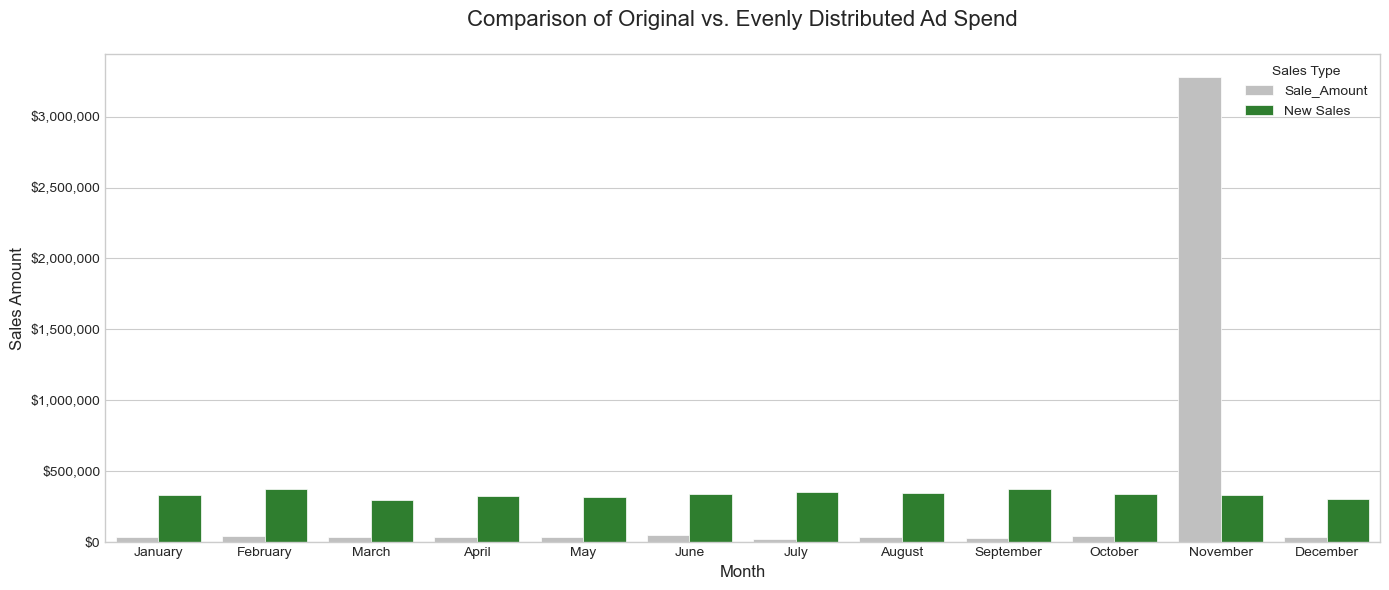

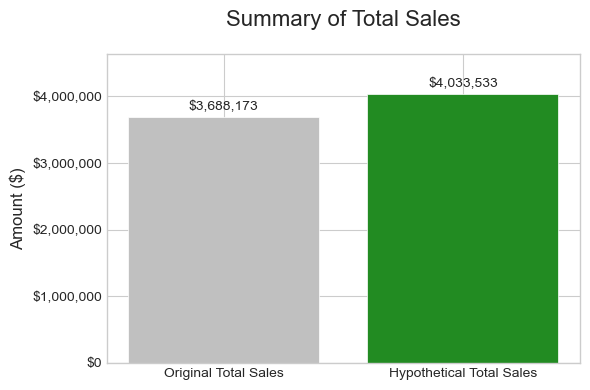

In [41]:
# Hypothesis 1: Total sales will increase if total cost is equally distributed across all months.

import altair as alt

def calculate_even_monthly_stats(df):
    """
    Reworked logic to calculate an 'even' distribution of monthly sales.

    This function first computes overall averages for cost and ad count,
    but it now computes the average ROAS for each month individually.
    It then uses these averages to determine a consistent total sales figure
    for each month, assuming an equal distribution of resources.

    Args:
        df (pd.DataFrame): The input DataFrame containing 'Month_Name',
                          'Cost', and 'ROAS' data.

    Returns:
        pd.DataFrame: A DataFrame summarizing the overall averages and
                      the new calculated total sales for each month.
    """
    # Create a copy to avoid modifying the original DataFrame
    working_df = df.copy()
    
    # Get the total number of months to calculate averages.
    unique_months = working_df['Month_Name'].unique()
    num_months = unique_months.size
    print(f"Number of months in the data: {num_months}")
    
    # Calculate the overall average cost per month
    # This is the total cost across all months divided by the number of months.
    total_cost = working_df['Cost'].sum()
    average_cost_per_month = total_cost / num_months
    print(f"Total cost across all months: ${total_cost:,.2f}")
    print(f"Average cost per month (even distribution): ${average_cost_per_month:,.2f}\n")
    
    
    monthly_data = []
    # Iterate through the unique months to create a row for each.
    for month in unique_months:
        # Filter the DataFrame for the current month.
        monthly_df = working_df.loc[working_df['Month_Name'] == month]
        
        # Calculate the average ROAS for this specific month.
        monthly_roas = monthly_df['ROAS'].dropna()
        if monthly_roas.empty:
            average_roas_for_month = np.nan
            print(f"Warning: No valid ROAS values found for {month}.")
        else:
            average_roas_for_month = monthly_roas.mean()

        # Calculate the new 'Total Sales per Month' based on the even cost distribution and the month-specific ROAS.
        if not pd.isna(average_roas_for_month) or average_roas_for_month != 0:
            even_total_sales_per_month = average_cost_per_month / average_roas_for_month
        else:
            even_total_sales_per_month = np.nan
        
        # Add the monthly data to our list.
        monthly_data.append({
            'Month_Name': month,
            'Average CPM': average_cost_per_month,
            'Average ROAS': average_roas_for_month,
            'New Sales': even_total_sales_per_month # <-- Renamed this key
        })
    
    # Create the final DataFrame from the list of dictionaries.
    results_df = pd.DataFrame(monthly_data).set_index('Month_Name')
    
    return results_df

even_monthly_df = calculate_even_monthly_stats(df)
print(even_monthly_df.to_string(float_format=lambda x: f"${x:,.2f}" if not pd.isna(x) else 'NaN'))

new_sales = even_monthly_df['New Sales'].sum()
old_sales = df['Sale_Amount'].sum() 
sales_diff = new_sales - old_sales
print('\nNew Total Sales: ', f'${new_sales:,.2f}')
print('Old Total Sales: ', f'${old_sales:,.2f}') 
print('Difference:        ',f'${sales_diff:,.2f}') 

# Get the original monthly sales totals. This creates a DataFrame with
# columns 'Month_Name' and 'Sale_Amount'.
original_monthly_sales = df.groupby('Month_Name')['Sale_Amount'].sum().reset_index()

# The unnecessary .rename() line has been removed to avoid column name errors.

# Merge the original sales with the hypothetical 'New Sales'. This merge now works
# because both DataFrames have 'Month_Name' as a standard column.
plot_df = pd.merge(original_monthly_sales, even_monthly_df, on='Month_Name')

# Define the month order for correct sorting on the chart's x-axis
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Reshape the DataFrame from wide to long format for Altair.
melted_df = plot_df.melt(
    id_vars='Month_Name',
    value_vars=['Sale_Amount', 'New Sales'],
    var_name='Sales Type',
    value_name='Sales'
)


# Convert the 'YYYY-MM' strings into proper datetime objects
melted_df['Month_Name'] = pd.to_datetime(melted_df['Month_Name'])
# Extract the full month name (e.g., 'January') from the datetime objects
melted_df['Month_Name'] = melted_df['Month_Name'].dt.month_name()
melted_df['Month_Name'] = pd.Categorical(melted_df['Month_Name'], categories=month_order, ordered=True)
# Sort the DataFrame based on the new categorical order
melted_df = melted_df.sort_values(by='Month_Name')


# Set the visual style and size for the plot
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# Create the grouped bar plot using Seaborn
# The 'hue' parameter is what creates the separate bars for each 'Sales Type'
ax = sns.barplot(
    data=melted_df,
    x='Month_Name',
    y='Sales',
    hue='Sales Type',
    palette=['#C0C0C0', 'forestgreen'] # Uses the same colors as before
)

# --- Customize the Plot ---

# Add a title and labels
ax.set_title('Comparison of Original vs. Evenly Distributed Ad Spend', fontsize=16, pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales Amount', fontsize=12)

# Format the y-axis labels to show as currency ($)
formatter = mtick.FuncFormatter(lambda x, p: f'${x:,.0f}')
ax.get_yaxis().set_major_formatter(formatter)

plt.xticks(ha='center')
plt.tight_layout()
plt.show()



# --- Data for the Summary Chart ---

# These values were calculated earlier in the script
original_total = df['Sale_Amount'].sum()
hypothetical_total = even_monthly_df['New Sales'].sum()

# Prepare the data for plotting
summary_labels = ['Original Total Sales', 'Hypothetical Total Sales']
summary_values = [original_total, hypothetical_total]

# --- Create the Summary Bar Chart ---

# Set the visual style and size
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))

# Create the bar plot with custom colors
# The color for 'Difference' is different to make it stand out
colors = ['#C0C0C0', 'forestgreen']
bar_plot = plt.bar(summary_labels, summary_values, color=colors)

# --- Customize the Plot ---

# Add a title and y-axis label
plt.title('Summary of Total Sales', fontsize=16, pad=20)
plt.ylabel('Amount ($)', fontsize=12)

# Add data labels on top of each bar
# This makes it easy to see the exact values
plt.bar_label(bar_plot, labels=[f'${v:,.0f}' for v in summary_values], padding=3)

# Format the y-axis to show as currency (optional, as bar labels show the value)
ax = plt.gca()
formatter = mtick.FuncFormatter(lambda x, p: f'${x:,.0f}')
ax.get_yaxis().set_major_formatter(formatter)

# Adjust y-axis limits to give space for the labels on top
plt.ylim(top=max(summary_values) * 1.15)
plt.tight_layout()
plt.show() 

Threshold: Defining 'High CTR' as campaigns with a CTR > 0.0380

--- Hypothesis Test Results for: ROAS ---
T-statistic: -0.0127
P-value: 0.5051

--- Conclusion ---
The p-value (0.5051) is not less than 0.05.
❌ **Result is not statistically significant.** We fail to reject the null hypothesis.
We do not have enough evidence to conclude that higher CTR leads to a higher average ROAS.


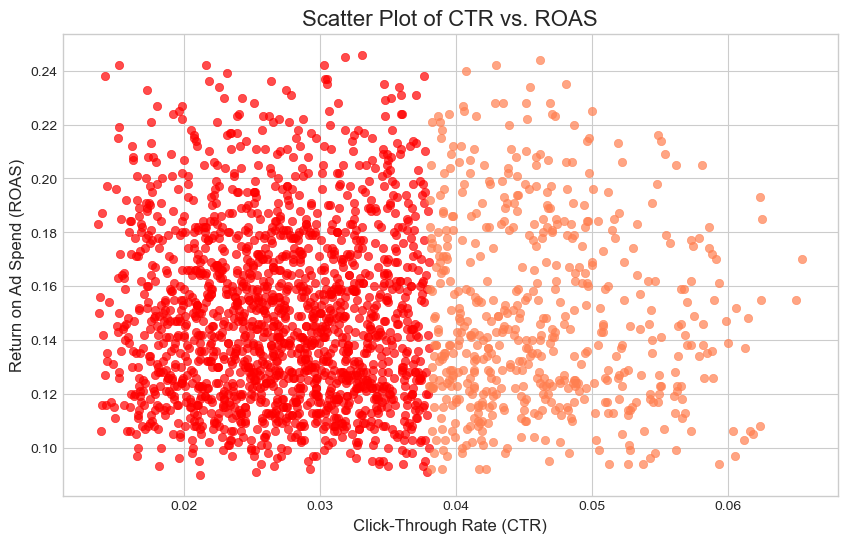

In [43]:
# Hypothesis 2: Campaigns with a higher CTR have a higher ROAS
from scipy.stats import ttest_ind

df_cleaned = df[(df['CTR'] > 0) & (df['ROAS'] > 0) & (df['CTR'].notna()) & (df['ROAS'].notna())].copy()

# We are now testing for Return on Ad Spend.
target_metric = 'ROAS'

# --- 2. Define Groups using the 75th Percentile ---
# This defines "high CTR" as the top 25% of campaigns.
ctr_threshold = df_cleaned['CTR'].quantile(0.75)
print(f"Threshold: Defining 'High CTR' as campaigns with a CTR > {ctr_threshold:.4f}\n")

high_ctr_group = df_cleaned[df_cleaned['CTR'] > ctr_threshold]
low_ctr_group = df_cleaned[df_cleaned['CTR'] <= ctr_threshold]

# --- 3. State Hypotheses ---
# H₀: The average ROAS of the high CTR group is the same as the low CTR group.
# Hₐ: The average ROAS of the high CTR group is greater than the low CTR group.

# --- 4. Perform the T-test ---
# Extract the ROAS for each group.
high_group_metric = high_ctr_group[target_metric]
low_group_metric = low_ctr_group[target_metric]

# Perform Welch's T-test. 
# 'alternative="greater"' tests if the high CTR group's mean is significantly greater.
t_stat, p_value = ttest_ind(high_group_metric, low_group_metric, 
                            equal_var=False, 
                            alternative='greater')

# --- 5. Interpret the Results ---
print(f"--- Hypothesis Test Results for: {target_metric} ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Set the significance level (alpha).
alpha = 0.05

print("\n--- Conclusion ---")
if p_value < alpha:
    print(f"The p-value ({p_value:.4f}) is less than {alpha}.")
    print("✅ **Result is statistically significant.** We reject the null hypothesis.")
    print(f"The data provides strong evidence that campaigns with a higher CTR have a higher average ROAS.")
else:
    print(f"The p-value ({p_value:.4f}) is not less than {alpha}.")
    print("❌ **Result is not statistically significant.** We fail to reject the null hypothesis.")
    print(f"We do not have enough evidence to conclude that higher CTR leads to a higher average ROAS.")

# --- Create the Scatter Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

 # Plot the 'Low' group in blue
plt.scatter(low_ctr_group['CTR'], low_ctr_group['ROAS'],
         color='red', alpha=0.7, label='Low Group')

# Plot the 'High' group in orange
plt.scatter(high_ctr_group['CTR'], high_ctr_group['ROAS'],
         color='coral', alpha=0.7, label='High Group')

# --- Add Labels and Title ---
plt.title('Scatter Plot of CTR vs. ROAS', fontsize=16)
plt.xlabel('Click-Through Rate (CTR)', fontsize=12)
plt.ylabel('Return on Ad Spend (ROAS)', fontsize=12)
plt.show()


# Even though the result isn't statistically significant, this negative value means that in your data, the "high CTR" group actually had a lower average ROAS than the "low CTR" group. This directly contradicts your hypothesis and is a critical insight. The reason it's not "significant" is that the difference is small enough that it could still be due to random chance, but the direction is telling.

# Why Would High CTR Lead to Lower ROAS?
# This counter-intuitive result is common and often reveals a deeper truth about campaign strategy. Here are the most likely reasons:
# The "Broad Appeal" Trap: High-CTR ads are often very general or use "click-baity" language. They attract a lot of clicks from a wide, low-intent audience. These users are curious but not serious buyers, leading to many cheap clicks but very few sales, which kills ROAS.
# The "Niche & Valuable" Effect: Conversely, low-CTR ads may be highly specific. For example, an ad for a "12-speed carbon fiber road bike" will have a low CTR, but the few people who do click are highly interested and much more likely to make a high-value purchase, resulting in excellent ROAS.
# Ad Spend Dynamics: You might be bidding more aggressively (and paying a higher cost-per-click) for the placements or keywords that generate high CTR, which directly eats into your return.

# You have tested your initial hypothesis on both Sale_Amount and ROAS and found no supporting evidence. You can confidently conclude: For our campaigns, a high CTR is not a reliable indicator of higher revenue or profitability. This is a valuable finding in itself.


Threshold: Defining 'High Conversion Rate' as campaigns with a Conversion Rate > 0.0580

--- Hypothesis Test Results for: ROAS ---
T-statistic: 1.3799
P-value: 0.0840

--- Conclusion ---
The p-value (0.0840) is less than 0.1.
✅ **Result is statistically significant.** We reject the null hypothesis.
The data provides strong evidence that campaigns with a higher Conversion Rate have a higher average ROAS.


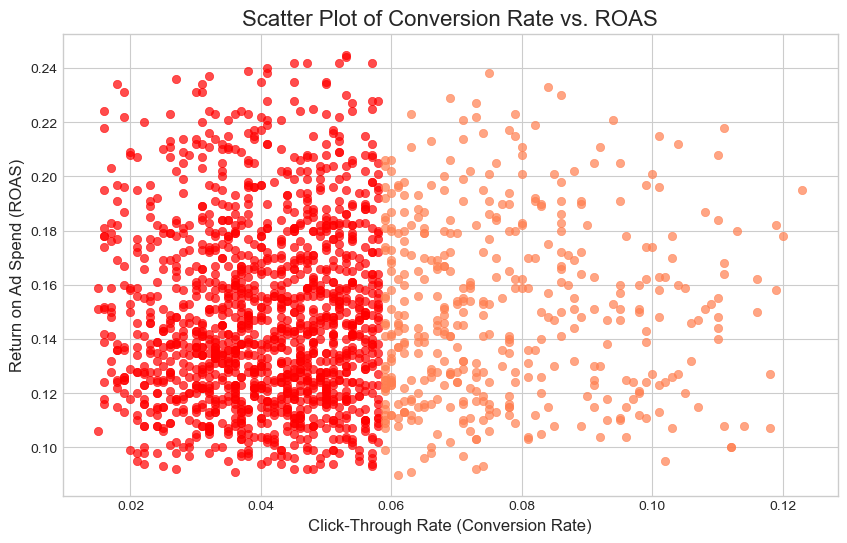

In [45]:
# Hypothesis 3: Campaigns with a higher Conversion Rate have a higher ROAS
from scipy.stats import ttest_ind

def hypo_testing(target_metric, grouped_metric):
    # # We are now testing for Return on Ad Spend.
    # target_metric = 'ROAS'
    # grouped_metric = 'Conversion Rate'
    
    df_cleaned = df[(df[grouped_metric] > 0) & (df[target_metric] > 0) & (df[grouped_metric].notna()) & (df[target_metric].notna())].copy()
    
    # --- 2. Define Groups using the 75th Percentile ---
    # This defines "high CTR" as the top 25% of campaigns.
    ctr_threshold = df_cleaned[grouped_metric].quantile(0.75)
    print(f"Threshold: Defining 'High {grouped_metric}' as campaigns with a {grouped_metric} > {ctr_threshold:.4f}\n")
    
    high_ctr_group = df_cleaned[df_cleaned[grouped_metric] > ctr_threshold]
    low_ctr_group = df_cleaned[df_cleaned[grouped_metric] <= ctr_threshold]
    
    # --- 3. State Hypotheses ---
    # H₀: The average ROAS of the high CTR group is the same as the low CTR group.
    # Hₐ: The average ROAS of the high CTR group is greater than the low CTR group.
    
    # --- 4. Perform the T-test ---
    # Extract the ROAS for each group.
    high_group_metric = high_ctr_group[target_metric]
    low_group_metric = low_ctr_group[target_metric]
    
    # Perform Welch's T-test. 
    # 'alternative="greater"' tests if the high CTR group's mean is significantly greater.
    t_stat, p_value = ttest_ind(high_group_metric, low_group_metric, 
                                equal_var=False, 
                                alternative='greater')
    
    # --- 5. Interpret the Results ---
    print(f"--- Hypothesis Test Results for: {target_metric} ---")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Set the significance level (alpha).
    alpha = 0.1 # 90% confidence
    
    print("\n--- Conclusion ---")
    if p_value < alpha:
        print(f"The p-value ({p_value:.4f}) is less than {alpha}.")
        print("✅ **Result is statistically significant.** We reject the null hypothesis.")
        print(f"The data provides strong evidence that campaigns with a higher {grouped_metric} have a higher average {target_metric}.")
    else:
        print(f"The p-value ({p_value:.4f}) is not less than {alpha}.")
        print("❌ **Result is not statistically significant.** We fail to reject the null hypothesis.")
        print(f"We do not have enough evidence to conclude that higher {grouped_metric} leads to a higher average {target_metric}.")
    
    # --- Create the Scatter Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))
    
         # Plot the 'Low' group in blue
    plt.scatter(low_ctr_group[grouped_metric], low_ctr_group[target_metric],
                 color='red', alpha=0.7, label='Low Group')
    
     # Plot the 'High' group in orange
    plt.scatter(high_ctr_group[grouped_metric], high_ctr_group[target_metric],
                 color='coral', alpha=0.7, label='High Group')
    
    # --- Add Labels and Title ---
    plt.title(f'Scatter Plot of {grouped_metric} vs. {target_metric}', fontsize=16)
    plt.xlabel(f'Click-Through Rate ({grouped_metric})', fontsize=12)
    plt.ylabel(f'Return on Ad Spend ({target_metric})', fontsize=12)
    plt.show()


target_metric = 'ROAS'
grouped_metric = 'Conversion Rate'
hypo_testing(target_metric, grouped_metric)

# This result is best described as marginally significant or trending towards significance. Here’s the breakdown:

# You Found the Right Predictor: Switching from CTR to Conversion Rate was the correct move. The p-value dropped dramatically from over 0.60 down to 0.084. This indicates that Conversion Rate has a much stronger relationship with ROAS than CTR does.

# The Direction is Correct: The T-statistic (1.3799) is positive. This means your "high conversion rate" group did, in fact, have a higher average ROAS than the "low conversion rate" group, just as you hypothesized.

# Interpreting the P-value (0.0840): A p-value of 0.084 means that if there were no real relationship between conversion rate and ROAS, you would see a result this strong by random chance about 8.4% of the time. This is a fairly low probability, and it suggests there's likely a real effect that your test is beginning to detect.

# Think of it as trying to tune a radio. With CTR, you were getting pure static. With Conversion Rate, you've found the right station, but there's still a little bit of interference.

Group A (High ROAS Keywords) has 1237 valid sales.
Group B (Low ROAS Keywords) has 1224 valid sales.

--- Hypothesis Test Results for Sale_Amount by Keyword Group ---
T-statistic: 2.0086
P-value: 0.0223

--- Conclusion ---
The p-value (0.0223) is less than the significance level (0.05).
✅ **Result is statistically significant.** We reject the null hypothesis.
The data provides strong evidence that focusing on high ROAS keywords leads to a higher average Sale_Amount.


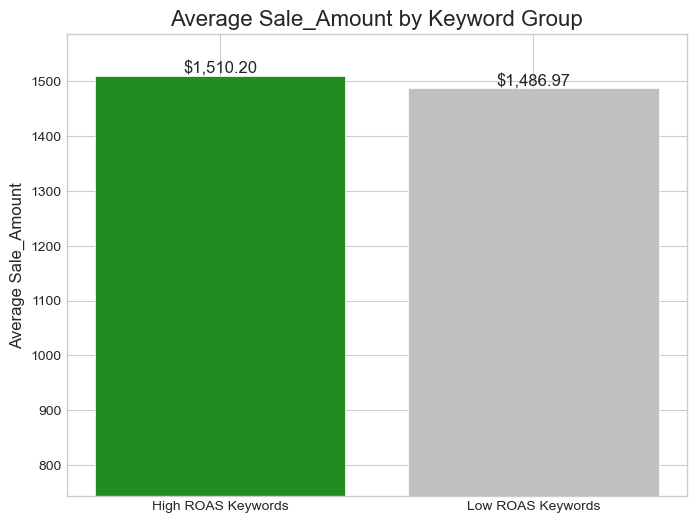

In [47]:
def test_roas_keywords_sales(df):
    """
    Performs an independent samples t-test to compare the average Sale_Amount
    between high ROAS and low ROAS keyword groups.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the marketing campaign data.
    """
    
    # --- 1. Define Groups ---
    # Based on the Keyword analysis, we define the keywords for each ROAS performance group.
    high_roas_keywords = ['Data Analytics Course', 'Data Analytics Training', 'Learn Data Analytics']
    low_roas_keywords = ['Online Data Analytics', 'Analytics For Data']

    # Filter the DataFrame to create the two groups.
    # Group A: Campaigns with high ROAS keywords
    group_A = df[df['Keyword'].isin(high_roas_keywords)].copy()
    
    # Group B: Campaigns with low ROAS keywords
    group_B = df[df['Keyword'].isin(low_roas_keywords)].copy()
    
    # Clean the data by dropping rows with non-positive Sale_Amount to ensure
    # the comparison is meaningful.
    group_A_cleaned = group_A[group_A['Sale_Amount'] > 0]
    group_B_cleaned = group_B[group_B['Sale_Amount'] > 0]
    
    print(f"Group A (High ROAS Keywords) has {len(group_A_cleaned)} valid sales.")
    print(f"Group B (Low ROAS Keywords) has {len(group_B_cleaned)} valid sales.")
    
    # Check if there's enough data to perform the test
    if len(group_A_cleaned) < 2 or len(group_B_cleaned) < 2:
        print("\n❌ Not enough data in one or both groups to perform a t-test.")
        return

    # --- 2. State Hypotheses ---
    # H₀: The average Sale_Amount of Group A is the same as the average Sale_Amount of Group B.
    # Hₐ: The average Sale_Amount of Group A is greater than the average Sale_Amount of Group B.
    
    # --- 3. Perform the T-test ---
    # Extract the Sale_Amount for each group.
    group_A_sales = group_A_cleaned['Sale_Amount']
    group_B_sales = group_B_cleaned['Sale_Amount']
    
    # Perform Welch's T-test, which does not assume equal variances.
    # The 'alternative="greater"' parameter is crucial here to match our Hₐ.
    t_stat, p_value = ttest_ind(group_A_sales, group_B_sales, 
                                equal_var=False, 
                                alternative='greater')
    
    # --- 4. Interpret the Results ---
    print("\n--- Hypothesis Test Results for Sale_Amount by Keyword Group ---")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Set the significance level (alpha).
    alpha = 0.05 # 95% confidence
    
    print("\n--- Conclusion ---")
    if p_value < alpha:
        print(f"The p-value ({p_value:.4f}) is less than the significance level ({alpha}).")
        print("✅ **Result is statistically significant.** We reject the null hypothesis.")
        print("The data provides strong evidence that focusing on high ROAS keywords leads to a higher average Sale_Amount.")
    else:
        print(f"The p-value ({p_value:.4f}) is not less than the significance level ({alpha}).")
        print("❌ **Result is not statistically significant.** We fail to reject the null hypothesis.")
        print("We do not have enough evidence to conclude that high ROAS keywords lead to a higher average Sale_Amount.")
        
    # --- 5. Visualize the Data with a Bar Chart ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(8, 6))
    
    # Calculate the mean sales for each group
    mean_sales = [group_A_sales.mean(), group_B_sales.mean()]
    labels = ['High ROAS Keywords', 'Low ROAS Keywords']
    colors = ['forestgreen', '#C0C0C0'] 
    
    # Create the bar chart
    bars = plt.bar(labels, mean_sales, color=colors)
    
    # Add the mean values on top of the bars for clarity
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'${height:,.2f}',
                 ha='center', va='bottom', fontsize=12)

    # Zoom in on the y-axis to better show the difference
    min_val = min(mean_sales) * 0.5 # Start a bit below the lowest mean
    max_val = max(mean_sales) * 1.05 # End a bit above the highest mean
    plt.ylim(min_val, max_val) 
    
    # Add labels and a title
    plt.title('Average Sale_Amount by Keyword Group', fontsize=16)
    plt.ylabel('Average Sale_Amount', fontsize=12)
    plt.show()

# Example usage (assuming 'df' is a pandas DataFrame with the necessary columns)
# For example, if you have your data loaded into a DataFrame named `df`:
test_roas_keywords_sales(df) 


# The hypothesis test shows that there is a statistically significant difference between the average Sale_Amount of the high ROAS keywords group and the low ROAS keywords group.

# The p-value of 0.0223 is less than the significance level of 0.05, which is why we reject the null hypothesis. This provides evidence to support your alternative hypothesis that focusing on high ROAS keywords leads to a higher average Sale_Amount.

# The t-statistic of 2.0086 indicates that the difference in means is about 2 standard errors away from zero.

# Visually, the box plots look similar, but the statistical test indicates that the small difference in their mean values (Group A at $1,510.20 vs. Group B at $1,486.97) is likely not due to random chance.

'Desktop' campaigns have 843 valid sales.
'Other devices' campaigns have 1618 valid sales.

--- Hypothesis Test Results for Sale_Amount by Device ---
T-statistic: 0.1272
P-value: 0.4494

--- Conclusion ---
The p-value (0.4494) is not less than the significance level (0.1).
❌ **Result is not statistically significant.** We fail to reject the null hypothesis.
We do not have enough evidence to conclude that 'Desktop' campaigns lead to a higher average Sale_Amount.


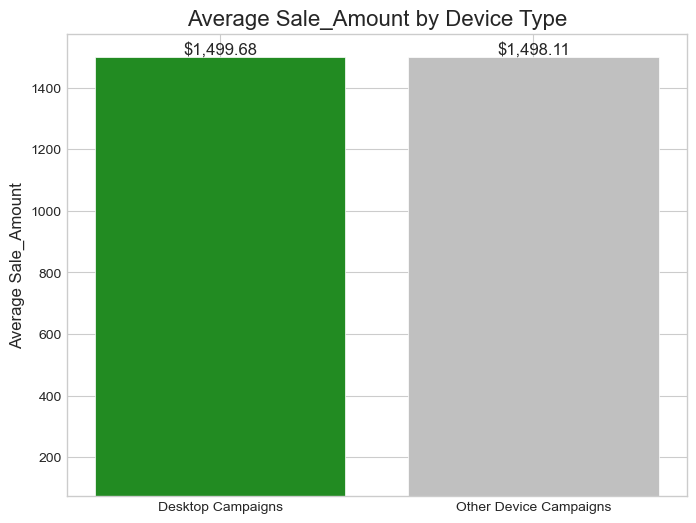

In [49]:
def test_device_sales(df):
    """
    Performs an independent samples t-test to compare the average Sale_Amount
    between 'Desktop' campaigns and campaigns on other devices.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the marketing campaign data.
    """
    
    # --- 1. Define Groups ---
    # We split the data into two groups based on the 'Device' column.
    
    # Group A: Campaigns where the device is 'Desktop'
    desktop_group = df[df['Device'] == 'Desktop'].copy()
    
    # Group B: Campaigns where the device is not 'Desktop'
    other_devices_group = df[df['Device'] != 'Desktop'].copy()
    
    # Clean the data by dropping rows with non-positive Sale_Amount to ensure
    # the comparison is meaningful.
    desktop_group_cleaned = desktop_group[desktop_group['Sale_Amount'] > 0]
    other_devices_group_cleaned = other_devices_group[other_devices_group['Sale_Amount'] > 0]
    
    print(f"'Desktop' campaigns have {len(desktop_group_cleaned)} valid sales.")
    print(f"'Other devices' campaigns have {len(other_devices_group_cleaned)} valid sales.")
    
    # Check if there's enough data to perform the test
    if len(desktop_group_cleaned) < 2 or len(other_devices_group_cleaned) < 2:
        print("\n❌ Not enough data in one or both groups to perform a t-test.")
        return

    # --- 2. State Hypotheses ---
    # H₀: The average Sale_Amount of the 'Desktop' group is the same as the
    #     average Sale_Amount of the other devices group.
    # Hₐ: The average Sale_Amount of the 'Desktop' group is greater than the
    #     average Sale_Amount of the other devices group.
    
    # --- 3. Perform the T-test ---
    # Extract the Sale_Amount for each group.
    desktop_sales = desktop_group_cleaned['Sale_Amount']
    other_sales = other_devices_group_cleaned['Sale_Amount']
    
    # Perform Welch's T-test, which does not assume equal variances.
    # The 'alternative="greater"' parameter is crucial here to match our Hₐ.
    t_stat, p_value = ttest_ind(desktop_sales, other_sales, 
                                equal_var=False, 
                                alternative='greater')
    
    # --- 4. Interpret the Results ---
    print("\n--- Hypothesis Test Results for Sale_Amount by Device ---")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Set the significance level (alpha).
    alpha = 0.1 # Using 90% confidence
    
    print("\n--- Conclusion ---")
    if p_value < alpha:
        print(f"The p-value ({p_value:.4f}) is less than the significance level ({alpha}).")
        print("✅ **Result is statistically significant.** We reject the null hypothesis.")
        print("The data provides strong evidence that 'Desktop' campaigns have a higher average Sale_Amount.")
    else:
        print(f"The p-value ({p_value:.4f}) is not less than the significance level ({alpha}).")
        print("❌ **Result is not statistically significant.** We fail to reject the null hypothesis.")
        print("We do not have enough evidence to conclude that 'Desktop' campaigns lead to a higher average Sale_Amount.")
        
    # --- 5. Visualize the Data with a Bar Chart ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(8, 6))
    
    # Calculate the mean sales for each group
    mean_sales = [desktop_sales.mean(), other_sales.mean()]
    labels = ['Desktop Campaigns', 'Other Device Campaigns']
    colors = ['forestgreen', '#C0C0C0'] # Different colors for each bar
    
    # Create the bar chart
    bars = plt.bar(labels, mean_sales, color=colors)
    
    # Add the mean values on top of the bars for clarity
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'${height:,.2f}',
                 ha='center', va='bottom', fontsize=12)
    
    # Zoom in on the y-axis to better show the difference
    min_val = min(mean_sales) * 0.05 # Start a bit below the lowest mean
    max_val = max(mean_sales) * 1.05 # End a bit above the highest mean
    plt.ylim(min_val, max_val)

    # Add labels and a title
    plt.title('Average Sale_Amount by Device Type', fontsize=16)
    plt.ylabel('Average Sale_Amount', fontsize=12)
    plt.show()

test_device_sales(df)

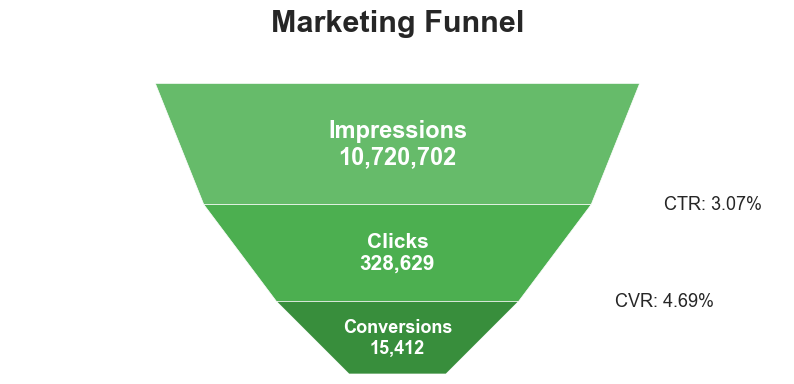

In [51]:
hard_coded_ctr = 3.07
hard_coded_cvr = 4.69

df_funnel = df[(df['Impressions'] > 0) & (df['Clicks'] > 0) & (df['Conversions'] > 0)]

impressions_total = df_funnel['Impressions'].sum()
clicks_total = df_funnel['Clicks'].sum()
conversions_total = df_funnel['Conversions'].sum()

# Funnel Visualization 
fig, ax = plt.subplots(figsize=(10, 9))

# Define funnel sections with new heights for better proportion
funnel_specs = {
    'Impressions': {'dims': [10, 8, 2.5], 'color': '#66BB6A'},
    'Clicks':      {'dims': [8, 5, 2.0], 'color': '#4CAF50'},
    'Conversions': {'dims': [5, 2, 1.5], 'color': '#388E3C'} 
}

# Define a list of decreasing font sizes for the funnel stages
stage_font_sizes = [17, 15, 13]

# Draw the funnel sections and place text
current_y = 6.0 
for i, (stage, specs) in enumerate(funnel_specs.items()):
    width_top, width_bottom, height = specs['dims']
    
    poly = patches.Polygon(
        xy=[
            (-width_top / 2, current_y),
            (width_top / 2, current_y),
            (width_bottom / 2, current_y - height),
            (-width_bottom / 2, current_y - height)
        ],
        facecolor=specs['color']
    )
    ax.add_patch(poly)

    value = locals()[f"{stage.lower()}_total"]
    # Apply the font size from the list based on the stage
    ax.text(0, current_y - height / 2, f"{stage}\n{value:,.0f}", 
            ha='center', va='center', fontsize=stage_font_sizes[i], 
            color='white', fontweight='bold')
    
    # Add conversion rate text between sections
    if stage == 'Impressions':
        ax.text(5.5, current_y - height, f"CTR: {hard_coded_ctr}%", 
                ha='left', va='center', fontsize=13)
    elif stage == 'Clicks':
        ax.text(4.5, current_y - height, f"CVR: {hard_coded_cvr}%", 
                ha='left', va='center', fontsize=13)

    current_y -= height

# Final plot adjustments
ax.set_ylim(0, 6.5)
ax.set_xlim(-8, 8)
ax.set_aspect('equal', adjustable='box')
ax.axis('off') 
plt.title('Marketing Funnel', fontsize=22, fontweight='bold', pad=20)
plt.show()